In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# %pip install plottable
from plottable import Table, ColDef
from matplotlib.colors import LinearSegmentedColormap
from plottable.cmap import normed_cmap

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# %pip install hockey-rink
from hockey_rink import NHLRink

# %pip install xgboost
import xgboost as xgb
from sklearn.metrics import log_loss
from sklearn.metrics import roc_auc_score

import networkx as nx

from scipy.stats import zscore


Events_raw = pd.read_parquet("events.parquet")
Games_raw = pd.read_parquet("games.parquet")
Players_raw = pd.read_parquet("players.parquet")
Stints_raw = pd.read_parquet("stints.parquet")
Tracking_raw = pd.read_parquet("tracking.parquet")

#   Faire un 'real_event_id' pour faciliter les merges et les repères après, car les sl_event_id est par match
Events_raw["real_event_id"] = Events_raw.index
Tracking_raw = Tracking_raw.merge(
    Events_raw[["sl_event_id", "game_id", "real_event_id"]],
    on=["sl_event_id", "game_id"],
    how="left",
)

In [12]:
# Ajout du tir précédent pour le pav plus tard avec leurs temps
Events_raw["prevshot_id_temp"] = Events_raw["real_event_id"].where(
    Events_raw["event_type"] == "shot"
)
Events_raw["prevshot_id"] = Events_raw.groupby(["game_id", "period"])[
    "prevshot_id_temp"
].ffill()

Events_raw["prevshot_time_temp"] = Events_raw["period_time"].where(
    Events_raw["event_type"] == "shot"
)
Events_raw["prevshot_temps"] = Events_raw.groupby(["game_id", "period"])[
    "prevshot_time_temp"
].ffill()

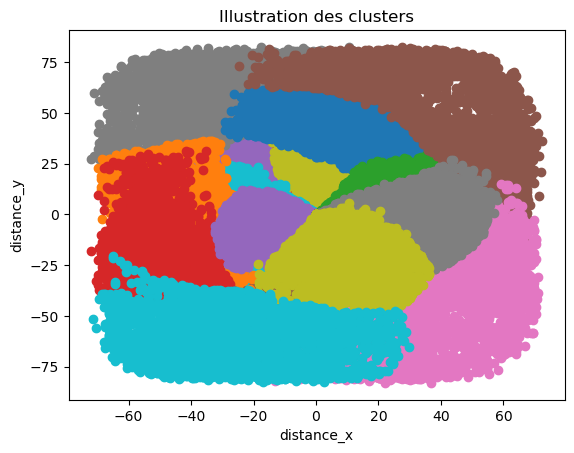

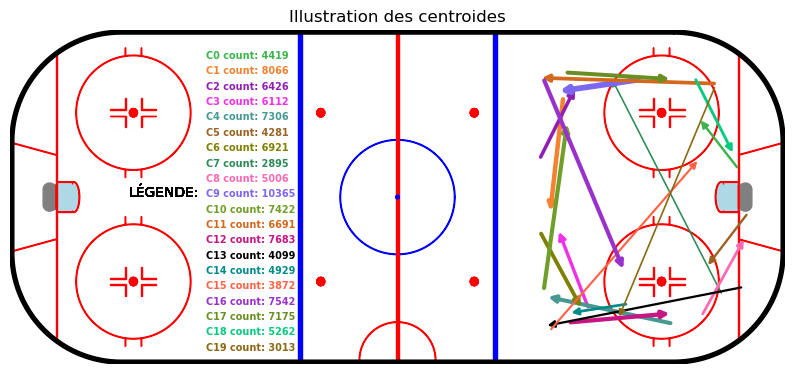

In [13]:
# --- MODULE POUR FAIRE PASS CLUSTERS POUR XG ---

# Garder seulement les évenements passes qui ont réussi
passes = Events_raw[
    ((Events_raw["event_type"] == "pass") & (Events_raw["outcome"] == "successful"))
].copy()

# foward fill les passes pour que les réceptions associées aux passes (pas nécessairement directement après l'évenement de passe)
#   aient le id des passes associés
events = Events_raw.copy()
events["pass_id_temp"] = events["real_event_id"].where(events["event_type"] == "pass")
events["pass_reliée"] = events.groupby(["game_id", "period"])["pass_id_temp"].ffill()
events["pass_reliée"] = events["pass_reliée"].fillna(-1).astype(int)

# garder seulement les réceptions réussites (ils ont maintenant le 'real_event_id' associé)
events_receptions = events[
    ((events["event_type"] == "reception") & (events["outcome"] == "successful"))
]
events_receptions_merge = events_receptions
events_receptions_merge = events_receptions_merge.rename(
    columns={
        "x_adj": "x_fin_adj",
        "y_adj": "y_fin_adj",
        "player_id": "joueur_rec_id",
        "player_name": "joueur_rec_nom",
        "real_event_id": "evenement_reception_id",
    }
)


events_receptions_merge = events_receptions_merge[
    [
        "x_fin_adj",
        "y_fin_adj",
        "joueur_rec_id",
        "joueur_rec_nom",
        "evenement_reception_id",
        "pass_reliée",
    ]
]

# merge pour bien cartographier la fin des passes
passes = passes.merge(
    events_receptions_merge, left_on="real_event_id", right_on="pass_reliée", how="left"
)

# trouver la distance des passes avec coordonnées de la fin de la passe - le début
passes["distance_x"] = passes["x_fin_adj"] - passes["x_adj"]
passes["distance_y"] = passes["y_fin_adj"] - passes["y_adj"]

# longueur avec pythagore
passes["longueur"] = np.sqrt(passes["distance_x"] ** 2 + passes["distance_y"] ** 2)

# utilisation de la méthode augmenter de arctan pour trouver l'angle du vecteur
passes["angle"] = np.arctan2(passes["distance_y"], passes["distance_x"])

# normaliser l'angle avec sin et cos
passes["cos"] = np.cos(passes["angle"])
passes["sin"] = np.sin(passes["angle"])

# Garder seulement les passes qui commences et qui termines en zone offensive
OZ_passes = passes[(passes["x_adj"] > 25) & (passes["x_fin_adj"] > 25)].copy()

# Garder seulement les valeurs qu'on veut en features
# Garde un vecteur de valeurs pour chaques passes
X_OZ = OZ_passes[["x_adj", "y_adj", "cos", "sin", "longueur"]].values

# Utilisation de standard scaler et fit_transform pour accorder une importance égale a chaque feature et les transformer en Z-score
# sinon la longueur va fort probablement dominer
scaler = StandardScaler()
X_OZ_scaled = scaler.fit_transform(X_OZ)

# changer ici pour avoir plus ou moins de clusters
k = 20

# Fonction Kmeans pour trouver les centroides optimals
kmeans_passes = KMeans(n_clusters=k, random_state=15)
OZ_passes["cluster"] = kmeans_passes.fit_predict(X_OZ_scaled)

# Maintenant que nous avons les centroides nous voulons l'illustrer
for clust in range(k):
    plot_data = OZ_passes[OZ_passes["cluster"] == clust]
    plt.scatter(plot_data["distance_x"], plot_data["distance_y"], label=f"c{clust}")
    plt.title("Illustration des clusters")
    plt.xlabel("distance_x")
    plt.ylabel("distance_y")


# trouver les centroides pour pouvoir les illustrers
centroids = pd.DataFrame(
    kmeans_passes.cluster_centers_, columns=["x_adj", "y_adj", "cos", "sin", "longueur"]
)

# Inverser le scaler car on veut les vrais données et non les normaliser
centroids = pd.DataFrame(
    scaler.inverse_transform(centroids),
    columns=["x_adj", "y_adj", "cos", "sin", "longueur"],
)

# Vue que les données ont pas de données sur la fin dans l'entrainement du kmeans il faut calculer le kmeans
centroids["x_fin_adj"] = centroids["x_adj"] + centroids["longueur"] * centroids["cos"]
centroids["y_fin_adj"] = centroids["y_adj"] + centroids["longueur"] * centroids["sin"]

# illuster les centroides sur une patinoires
patinoire = NHLRink()

figure, axis = plt.subplots(figsize=(10, 5))
patinoire.draw(ax=axis)

centroids["count"] = OZ_passes["cluster"].value_counts()


# Trouver avec chatgpt car je n'ai pas le gout de trouver toutes les couleurs manuellemement
couleurs = [
    "#3cb44b",  # bright green
    "#f58231",  # orange
    "#911eb4",  # purple
    "#f032e6",  # magenta
    "#469990",  # teal
    "#9A6324",  # brown
    "#808000",  # olive
    "#2e8b57",  # sea green
    "#ff69b4",  # hot pink
    "#7b68ee",  # medium slate purple
    "#709f29",  # yellow green
    "#d2691e",  # chocolate
    "#c71585",  # medium violet red
    "#000000",  # chartreuse
    "#008b8b",  # dark cyan
    "#ff6347",  # tomato orange
    "#9932cc",  # dark orchid
    "#6b8e23",  # olive drab
    "#04cb7f",  # medium spring green
    "#8b6914",  # dark goldenrod
    "#556b2f",  # dark olive
    "#ff8c00",  # dark orange
    "#20b2aa",  # light sea green
    "#9400d3",  # dark violet
    "#228b22",  # forest green
    "#e6a817",  # golden yellow
    "#5f9ea0",  # cadet blue-green
    "#b8860b",  # dark goldenrod 2
    "#00c957",  # emerald
    "#cc5500",  # burnt orange
]

axe_x_texte = -50
axe_y_texte = 36

for t, data in centroids.iterrows():
    axis.annotate(
        "",
        xy=(data["x_fin_adj"], data["y_fin_adj"]),
        xytext=(data["x_adj"], data["y_adj"]),
        arrowprops=dict(arrowstyle="-|>", lw=data["count"] / 2500, color=couleurs[t]),
        zorder=5,
    )
    axis.text(
        axe_x_texte,
        axe_y_texte,
        f'C{t} count: {data["count"].astype(int)}',
        fontsize=7,
        color=couleurs[t],
        fontweight="bold",
        zorder=10,
    )
    axe_y_texte = axe_y_texte - 4
    axis.text(-70, 0, "LÉGENDE:", zorder=5)
    plt.title("Illustration des centroides")

In [14]:
# --- MODULE POUR FAIRE FEATURES POUR XG ---

# On garde seulement les events qui sont des tirs
shots = Events_raw[Events_raw["event_type"] == "shot"].copy()

# On ajoute les différentes valeurs du nombre de joueurs par équipes pour savoir si on est en pp ou pk
stint_strength = Stints_raw[
    [
        "game_id",
        "game_stint",
        "n_home_skaters",
        "n_away_skaters",
        "is_home_net_empty",
        "is_away_net_empty",
        "home_score",
        "away_score",
    ]
].drop_duplicates(subset=["game_id", "game_stint"])
shots = shots.merge(
    stint_strength, on=["game_id", "game_stint"], how="left", validate="many_to_one"
)

# on merge les infos sur c'est qui l'équipe
shots = shots.merge(
    Games_raw[["game_id", "home_team", "away_team"]], on="game_id", how="left"
)


# ------------------------------ IS_REBOUND ------------------------------
# On calcul pour voir si ya un tir fait par l'équipe a l'interieur de 2 seconde pour détrerminer si le tir présent est un rebond
# variable binaire

shots = shots.sort_values(["game_id", "period", "period_time"]).reset_index(drop=True)
shots["temps_event_avant"] = shots["period_time"].shift(1)
shots["time_diff"] = shots["period_time"] - shots["temps_event_avant"]
shots["is_rebound"] = ((shots["period_time"] - shots["temps_event_avant"]) <= 2).astype(
    int
)

# ------------------------------ IS_POWERPLAY ------------------------------
# On détermine si l'équipe qui tire à plus de joueurs que l'autre équipe
# is_powerplay = 1 si pp ou 0 si non
shots["is_powerplay"] = (
    (
        (shots["team"] == shots["home_team"])
        & (shots["n_home_skaters"] > shots["n_away_skaters"])
    )
    | (
        (shots["team"] == shots["away_team"])
        & (shots["n_away_skaters"] > shots["n_home_skaters"])
    )
).astype(int)


# ------------------------------ PREVIOUS_CLUSTER ------------------------------
# On calcul si la passe vient 3 seconde avant le tir et à quelle cluster on peut la reliée
OZ_passes_shots = OZ_passes.copy()

# On copie les temps et cluster de chaque passe pour faire ffill plus tard
OZ_passes_shots["Time_pass_avant"] = OZ_passes_shots["period_time"]
OZ_passes_shots["pass_avant_cluster"] = OZ_passes_shots["cluster"]

# On concat avec les tirs pour faire ffill
shots_passes_concat = pd.concat([OZ_passes_shots, shots])
shots_passes_concat = shots_passes_concat.sort_values(
    ["game_id", "period", "period_time"]
).reset_index(drop=True)
shots_passes_concat["Time_pass_avant"] = shots_passes_concat.groupby(
    ["game_id", "period"]
)["Time_pass_avant"].ffill()
shots_passes_concat["pass_avant_cluster"] = shots_passes_concat.groupby(
    ["game_id", "period"]
)["pass_avant_cluster"].ffill()

# on prend le temps depuis la derniere passe
shots_passes_concat["temps_depuis_passe"] = (
    shots_passes_concat["period_time"] - shots_passes_concat["Time_pass_avant"]
)

# On remet les tirs et les nouvelles colonnes dans le df shots
shots_passes_merge = shots_passes_concat[shots_passes_concat["event_type"] == "shot"]
shots = shots.merge(
    shots_passes_merge[
        ["temps_depuis_passe", "Time_pass_avant", "pass_avant_cluster", "real_event_id"]
    ],
    on="real_event_id",
)

# On fait une nouvelle colonne qui s'assure qu'on comptabilise seulement les tirs qui sont à l'intérieur de 3 secondes
shots["prev_oz_pass_cluster"] = shots["pass_avant_cluster"].where(
    shots["temps_depuis_passe"] <= 3
)

# On ajoute un binary label pour l'entrainement
for i in range(k):
    shots[f"is_c{i}"] = (shots["prev_oz_pass_cluster"] == i).astype(int)

# ------------------------------ DISTANCE AU BUT ------------------------------
# On calcul la distance du tirs au milieu du but

# coordonnées du milieu du but
but_x = 89
but_y = 0

# meme stratégie que pour les passes: Utilisation de pythagore
shots["distance"] = np.sqrt(
    (but_x - shots["x_adj"]) ** 2 + (but_y - shots["y_adj"]) ** 2
)

# ------------------------------ ANGLE ------------------------------
# On calcule l'angle du tirs par rapport au centre du but

# meme stratégie que pour les passes: arctan 2 pour trouver l'angle
shots["angle"] = np.arctan2(np.abs(shots["y_adj"]), but_x - shots["x_adj"])


# ------------------------------ DEF LE PLUS PROCHE ------------------------------
# On calcule la distance du défenseur le plus proche aux coordonées du tir

# on transfert seulement les informations utiles des tirs
shots_2 = shots[["game_id", "real_event_id", "team_id", "x", "y"]].copy()
# on change les noms pour pas de confusion ou de _x _y qui gosse
shots_2.columns = ["game_id", "real_event_id", "shot_team", "x_shot", "y_shot"]

# copier les données de localisation de tous les joueurs
tracking_2 = Tracking_raw[
    ["game_id", "real_event_id", "team_id", "tracking_x", "tracking_y"]
].copy()

# merge pour l
shots_3 = shots_2.merge(tracking_2, on=["game_id", "real_event_id"], how="left")

# garder seuelemnt les gens qui sont pas dand l'équipe qui tir
shots_3 = shots_3[shots_3["shot_team"] != shots_3["team_id"]]

# trouver la distance au tir
shots_3["dist_to_shot"] = np.sqrt(
    (shots_3["x_shot"] - shots_3["tracking_x"]) ** 2
    + (shots_3["y_shot"] - shots_3["tracking_y"]) ** 2
)

# trouver le plus petit de tous
def_plus_proche = (
    shots_3.groupby(["game_id", "real_event_id"])["dist_to_shot"].min().reset_index()
)

def_plus_proche.rename(columns={"dist_to_shot": "dist_def_proche"}, inplace=True)

# merge avec le main df
shots = shots.merge(def_plus_proche, on=["game_id", "real_event_id"], how="left")


# ------------------------------ NOMBRE DE DEF DANS LE CHEMIN ------------------------------
# Trouver le nombre de défenseur entre la localisation du tir et le centre du but en tracant une ligne et en observant la distance de chaque défenseur a cette ligne


# Apres beaucoup de recherche sur comment trouver ceci voici mon adaptation de plusieurs repo en sport et en projection automobile
# trouver sur (https://github.com/LuckierBread/YOLOv9-Car-Counter/blob/main/Yolov9_Car_Counter.ipynb) et adapter à nos besoins
def point_to_segment(
    def_loc_x, def_loc_y, start_loc_x, start_loc_y, end_loc_x, end_loc_y
):
    # transforme les coordonnées en vecteurs
    def_loc = np.array([def_loc_x, def_loc_y])
    start_loc = np.array([start_loc_x, start_loc_y])
    end_loc = np.array([end_loc_x, end_loc_y])
    # vecteur du segement du tir
    point1 = end_loc - start_loc
    # np.dot utiliser pour une projection et déterminer la portion du ségement
    point1_nomr = np.dot(point1, point1)
    # vecteur de la distance entre les défenseur et le début du tir
    point2 = def_loc - start_loc
    # projection avec les longuers scalaires (dot product) pour déterminer si le joueurs est sur le ségment du tir
    proj = np.dot(point2, point1) / point1_nomr
    # on détermine si le joueur est en arriere du tir il n'a pas d'éffet et s'il est arriere du but il a aussi pas d'incidence sur le tir
    on_segment = (proj >= 0) & (proj <= 1)
    # on trouve la distance des points avec np.outer pour que ca nous redonne une matrice des scalaires de la distance de nos points
    proj_points = start_loc + np.outer(proj[on_segment], point1)
    # Calcul de la distance au vecteur de tir
    dist_to_proj = np.linalg.norm(proj_points - def_loc[on_segment], axis=1)
    # On prend tout les points et on rempli avec inf pour les défenseurs hors du ségments
    distances = np.full_like(proj, np.inf)
    # On rempli le tout avec les distances
    distances[on_segment] = dist_to_proj
    return distances


# .apply a toutes les lignes une par une pour pas mess up les arrays
shots_3["lane_dist"] = shots_3.apply(
    lambda ligne: point_to_segment(
        ligne["tracking_x"],
        ligne["tracking_y"],
        ligne["x_shot"],
        ligne["y_shot"],
        but_x,
        but_y,
    ),
    axis=1,
)
Distance_acceptable = 2  # pieds de la ligne de tir
# On compte le nombre de défenseurs par tirs avec .size
lane_blockers = (
    shots_3[shots_3["lane_dist"] <= Distance_acceptable]
    .groupby(["game_id", "real_event_id"])
    .size()
    .reset_index(name="lane_defender_count")
)
# merge back au main df
shots = shots.merge(lane_blockers, on=["game_id", "real_event_id"], how="left").fillna(
    {"lane_defender_count": 0}
)

# ------------------------------ Goal Flag ------------------------------
# On détermine si le tir est un but ou non pour l'entrainement du modèle
shots["goal_flag"] = shots["flags"].str.contains("goal", na=False).astype(int)

# ------------------------------ FILTRAGE FINAL ------------------------------
# On enleve les buts à filet désert et les tirs blocked

# la description des tirs ont une mention blocked si le tir est blocké
shots = shots[~shots["description"].str.lower().str.contains("block", na=False)]
# enlever les empty net pour pas avoir des buts fausser
# on regarde si le joueur tir sur le but home ou away et si ce but est vide
shots["is_empty_net"] = np.where(
    shots["team"] == shots["home_team"],
    shots["is_away_net_empty"].fillna(0),
    shots["is_home_net_empty"].fillna(0),
).astype(int)
shots = shots[shots["is_empty_net"] == 0]

In [15]:
# --- MODULE POUR MODÈLE XGBOOST POUR EXPECTED GOAL ---

# Split les différentes games pour split les tirs selon les différentes games
# on garde les games id uniques
games = shots["game_id"].unique()
# On les shuffles pour random avec seed pour constance des résultat
np.random.seed(82)
np.random.shuffle(games)

# Longueur pour splitting
n_games = len(games)

# train test val split avec splitting (70% train, 15% test, 15% validation)
train_games = games[: int(0.7 * n_games)]
val_games = games[int(0.7 * n_games) : int(0.85 * n_games)]
test_games = games[int(0.85 * n_games) :]

# split des actuals tirs et pas seulement des games
train = shots[shots["game_id"].isin(train_games)]
val = shots[shots["game_id"].isin(val_games)]
test = shots[shots["game_id"].isin(test_games)]

# Ici on détermine les features avec lesquels ont veut entrainer le modèle
xgb_base_features = [
    "distance",
    "angle",
    "dist_def_proche",
    "lane_defender_count",
    "is_powerplay",
]
# On ajout tous les features de clusters
xgb_features = xgb_base_features + [f"is_c{k}" for k in range(k)]

# On garde seulememnt les colonnes des features voulu
features_train = train[xgb_features].fillna(0)
features_val = val[xgb_features].fillna(0)
features_test = test[xgb_features].fillna(0)

# Notre goal_flag donc si c'est un but
goal_train = train["goal_flag"]
goal_val = val["goal_flag"]
goal_test = test["goal_flag"]

# Transformation de dataframes en DMatrix optimisé pour le XGBoost qu'on va utilisé plus tard
mlm_matrix_train = xgb.DMatrix(features_train, label=goal_train)
mlm_matrix_val = xgb.DMatrix(features_val, label=goal_val)
mlm_matrix_test = xgb.DMatrix(features_test, label=goal_test)

# Parametres choisi pour l'entrainement
params = {
    "objective": "binary:logistic",  # but = 1 pas de but = 0 on calcule la prédiction entre chaque
    "eval_metric": "logloss",  # le modele évalue avec le logloss
    "eta": 0.01,  # learning rate bas mais beacoup détape
    "subsample": 0.9,  # proportion des tirs utilisé
    "seed": 82,
}

# entrainement du modele
model_xgb_xg = xgb.train(
    params,
    mlm_matrix_train,
    num_boost_round=500,  # max ronde d'entraiment
    evals=[
        (mlm_matrix_train, "train"),
        (mlm_matrix_val, "val"),
    ],  # on évalue avec le train et valide avec le val
    early_stopping_rounds=30,  # Si on fait pas de progres apres 30 ronde on arrete
    verbose_eval=100,
)  # nous dit la progression à chaque 100 rondes


# prédiction sur le set de test pour évaluer la performance finale
y_test_prediction = model_xgb_xg.predict(mlm_matrix_test)

# prédiction sur tous les tirs pour avoir le xg de chaque tir
shots_matrix = xgb.DMatrix(shots[xgb_features])
shots["XGB_xg"] = model_xgb_xg.predict(shots_matrix)

# calcul des métriques de performance du modèle
corr_shot = np.corrcoef(goal_test, y_test_prediction)[0, 1]
auc_shot = roc_auc_score(goal_test, y_test_prediction)
logloss_shot = log_loss(goal_test, y_test_prediction)

# affichage des métriques finales
print("Correlation:", np.corrcoef(goal_test, y_test_prediction)[0, 1])
print("AUC:", roc_auc_score(goal_test, y_test_prediction))
print("LogLoss:", log_loss(goal_test, y_test_prediction))

[0]	train-logloss:0.23852	val-logloss:0.24996
[100]	train-logloss:0.20960	val-logloss:0.23208
[200]	train-logloss:0.20107	val-logloss:0.22964
[296]	train-logloss:0.19639	val-logloss:0.22950
Correlation: 0.2629869085803237
AUC: 0.7525575534206853
LogLoss: 0.2120873652952336


In [16]:
# Meme logique que avec les shots mais avec les passes


def getXgEvent_pass(event_df, OZ_passes, fin_de_pass=False):
    event_i = event_df.copy()
    stint_strength_e = Stints_raw.merge(
        event_i[["game_id", "game_stint"]], on=["game_id", "game_stint"], how="inner"
    )[
        [
            "game_id",
            "game_stint",
            "n_home_skaters",
            "n_away_skaters",
            "is_home_net_empty",
            "is_away_net_empty",
            "home_score",
            "away_score",
        ]
    ].drop_duplicates()

    event_i = event_i.merge(
        stint_strength_e,
        on=["game_id", "game_stint"],
        how="left",
        validate="many_to_one",
    )
    event_i = event_i.merge(
        Games_raw[["game_id", "home_team", "away_team"]], on="game_id", how="left"
    )

    if fin_de_pass == True:
        x_col = "x_fin_adj"
        y_col = "y_fin_adj"
        # ----------------------rebound
        event_i["is_rebound"] = 0
    else:
        x_col = "x_adj"
        y_col = "y_adj"
        # ------------------rebound
        event_i["is_rebound"] = (
            (event_i["period_time"] - event_i["prevshot_temps"]) <= 2
        ).astype(int)

    but_x, but_y = 89, 0

    # ---------------distance
    event_i["distance"] = np.sqrt(
        (but_x - event_i["x_adj"]) ** 2 + (but_y - event_i["y_adj"]) ** 2
    )

    # -------------------angle
    event_i["angle"] = np.arctan2(np.abs(event_i["y_adj"]), but_x - event_i["x_adj"])

    # ------------------------CLUSTERS
    OZ_passes_event_i = OZ_passes.copy()
    OZ_passes_event_i["temp_temp"] = 0
    # On copie les temps et cluster de chaque passe pour faire ffill plus tard
    OZ_passes_event_i["Time_pass_avant_pav"] = OZ_passes_event_i["period_time"]
    OZ_passes_event_i["pass_avant_cluster_pav"] = OZ_passes_event_i["cluster"]
    OZ_passes_event_i["Time_pass_avant_pav_avant"] = OZ_passes_event_i[
        "period_time"
    ].shift(1)
    OZ_passes_event_i["pass_avant_cluster_pav_avant"] = OZ_passes_event_i[
        "cluster"
    ].shift(1)
    # On concat avec les tirs pour faire ffill
    event_i["temp_temp"] = 1
    event_i_passes_concat = pd.concat([OZ_passes_event_i, event_i])
    event_i_passes_concat = event_i_passes_concat.sort_values(
        ["game_id", "period", "period_time", "temp_temp"]
    ).reset_index(drop=True)
    event_i_passes_concat["Time_pass_avant_pav"] = event_i_passes_concat.groupby(
        ["game_id", "period"]
    )["Time_pass_avant_pav"].ffill()
    event_i_passes_concat["pass_avant_cluster_pav"] = event_i_passes_concat.groupby(
        ["game_id", "period"]
    )["pass_avant_cluster_pav"].ffill()
    event_i_passes_concat["Time_pass_avant_pav_avant"] = event_i_passes_concat.groupby(
        ["game_id", "period"]
    )["Time_pass_avant_pav_avant"].ffill()
    event_i_passes_concat["pass_avant_cluster_pav_avant"] = (
        event_i_passes_concat.groupby(["game_id", "period"])[
            "pass_avant_cluster_pav_avant"
        ].ffill()
    )
    # on prend le temps depuis la derniere passe
    event_i_passes_concat["temps_depuis_passe"] = (
        event_i_passes_concat["period_time"]
        - event_i_passes_concat["Time_pass_avant_pav"]
    )
    # On remet les tirs et les nouvelles colonnes dans le df shots
    event_i_passes_merge = event_i_passes_concat[
        event_i_passes_concat["temp_temp"] == 1
    ]
    event_i = event_i.merge(
        event_i_passes_merge[
            [
                "temps_depuis_passe",
                "Time_pass_avant_pav",
                "pass_avant_cluster_pav",
                "Time_pass_avant_pav_avant",
                "pass_avant_cluster_pav_avant",
                "real_event_id",
            ]
        ],
        on="real_event_id",
    )

    # On fait une nouvelle colonne qui s'assure qu'on comptabilise seulement les tirs qui sont à l'intérieur de 3 secondes
    if fin_de_pass == True:
        event_i["prev_oz_pass_cluster"] = event_i["pass_avant_cluster_pav"]
    else:
        event_i["prev_oz_pass_cluster"] = event_i["pass_avant_cluster_pav_avant"].where(
            event_i["Time_pass_avant_pav_avant"] <= 3
        )
    # On ajoute un binary label pour l'entrainement
    for i in range(k):
        event_i[f"is_c{i}"] = (event_i["prev_oz_pass_cluster"] == i).astype(int)

    # ------------- powerplay
    event_i["is_powerplay"] = (
        (
            (event_i["team"] == event_i["home_team"])
            & (event_i["n_home_skaters"] > event_i["n_away_skaters"])
        )
        | (
            (event_i["team"] == event_i["away_team"])
            & (event_i["n_away_skaters"] > event_i["n_home_skaters"])
        )
    ).astype(int)

    # ---------------------def le plus proche
    # on transfert seulement les informations utiles des tirs
    event_i_2 = event_i[["game_id", "real_event_id", "team_id", x_col, y_col]].copy()
    # on change les noms pour pas de confusion ou de _x _y qui gosse
    event_i_2.columns = ["game_id", "real_event_id", "shot_team", "x_pass", "y_pass"]
    # copier les données de localisation de tous les joueurs
    tracking_2 = Tracking_raw[
        ["game_id", "real_event_id", "team_id", "tracking_x", "tracking_y"]
    ].copy()
    # merge pour l
    event_i_3 = event_i_2.merge(tracking_2, on=["game_id", "real_event_id"], how="left")
    # garder seuelemnt les gens qui sont pas dand l'équipe qui tir
    event_i_3 = event_i_3[event_i_3["shot_team"] != event_i_3["team_id"]]
    # trouver la distance au tir
    event_i_3["dist_to_shot"] = np.sqrt(
        (event_i_3["x_pass"] - event_i_3["tracking_x"]) ** 2
        + (event_i_3["y_pass"] - event_i_3["tracking_y"]) ** 2
    )
    # trouver le plus petit de tous
    def_plus_proche_event_i = (
        event_i_3.groupby(["game_id", "real_event_id"])["dist_to_shot"]
        .min()
        .reset_index()
    )
    def_plus_proche_event_i.rename(
        columns={"dist_to_shot": "dist_def_proche"}, inplace=True
    )
    # merge avec le main df
    event_i = event_i.merge(
        def_plus_proche_event_i, on=["game_id", "real_event_id"], how="left"
    )

    # --------------------------- nombre de def dans la lane
    event_i_3["lane_dist"] = event_i_3.apply(
        lambda ligne: point_to_segment(
            ligne["tracking_x"],
            ligne["tracking_y"],
            ligne["x_pass"],
            ligne["y_pass"],
            but_x,
            but_y,
        ),
        axis=1,
    )
    Distance_acceptable_passe = 2  # pieds de la ligne de tir
    # On compte le nombre de défenseurs par tirs avec .size
    lane_blockers_passe = (
        event_i_3[event_i_3["lane_dist"] <= Distance_acceptable_passe]
        .groupby(["game_id", "real_event_id"])
        .size()
        .reset_index(name="lane_defender_count")
    )

    event_i = event_i.merge(
        lane_blockers_passe, on=["game_id", "real_event_id"], how="left"
    ).fillna({"lane_defender_count": 0})

    event_i["XGB_xg"] = model_xgb_xg.predict(xgb.DMatrix(event_i[xgb_features]))
    return event_i[["real_event_id", "XGB_xg", "prev_oz_pass_cluster"]]


# xg calculé au début de la passe (avant)
xg_avant = getXgEvent_pass(OZ_passes, OZ_passes, fin_de_pass=False)
xg_avant.columns = ["real_event_id", "XGB_xg_avant", "prev_oz_pass_cluster_avant"]

# xg calculé à la fin de la passe (après)
xg_apres = getXgEvent_pass(OZ_passes, OZ_passes, fin_de_pass=True)
xg_apres.columns = ["real_event_id", "XGB_xg_apres", "prev_oz_pass_cluster_apres"]

# on merge les deux xg sur les passes
OZ_passes_PAV = OZ_passes.copy()
OZ_passes_PAV = OZ_passes_PAV.merge(xg_avant, on="real_event_id", how="left")
OZ_passes_PAV = OZ_passes_PAV.merge(xg_apres, on="real_event_id", how="left")

# PAV = différence de xg créée par la passe (xg après - xg avant)
OZ_passes_PAV["PAV"] = OZ_passes_PAV["XGB_xg_apres"] - OZ_passes_PAV["XGB_xg_avant"]

In [17]:
# on sort les évenements par ordre chronologique pour les opérations de bfill
passf_next = Events_raw.sort_values(["game_id", "period", "period_time"]).copy()

# évenements qui terminent une séquence de passe
resolution_events = ["reception", "failedpasslocation", "block"]

# on ajoute un id de ligne pour référencer les positions dans le df
passf_next["row_id"] = np.arange(len(passf_next))

# flag binaire pour identifier les évenements de résolution
passf_next["is_resolution"] = passf_next["event_type"].isin(resolution_events)

# on garde l'index des résolutions pour le bfill
passf_next["resolution_id"] = passf_next.index.where(passf_next["is_resolution"])

# bfill pour propager la prochaine résolution à chaque évenement qui la précède
passf_next["prochaine_resolution_id"] = passf_next.groupby("game_id")[
    "resolution_id"
].bfill()

# flag binaire pour identifier les passes
passf_next["is_pass"] = passf_next["event_type"] == "pass"

# on garde l'index des passes pour le bfill
passf_next["pass_id"] = np.where(
    passf_next["event_type"] == "pass", passf_next.index, np.nan
)

# bfill pour trouver la prochaine passe et shift(-1) pour exclure la passe courante
passf_next["next_pass_id"] = passf_next.groupby("game_id")["pass_id"].bfill()
passf_next["next_pass_id"] = passf_next.groupby("game_id")["next_pass_id"].shift(-1)

# meme logique pour les lpr (last play recorded) comme filet de sécurité si pas de résolution trouvée
passf_next["is_lpr"] = passf_next["event_type"] == "lpr"
passf_next["lpr_id"] = passf_next.index.where(passf_next["is_lpr"])

# bfill pour propager le prochain lpr à chaque évenement qui le précède
passf_next["next_lpr_id"] = passf_next.groupby("game_id")["lpr_id"].bfill()

# garder seulement les passes
passes_f = passf_next[passf_next["event_type"] == "pass"].copy()

# on choisit la fin de la passe: priorité à la résolution si elle arrive avant la prochaine passe, sinon le lpr
passes_f["fin_final_id"] = np.where(
    (
        passes_f["prochaine_resolution_id"].notna()
        & (
            passes_f["next_pass_id"].isna()
            | (passes_f["prochaine_resolution_id"] < passes_f["next_pass_id"])
        )
    ),
    passes_f["prochaine_resolution_id"],
    passes_f["next_lpr_id"],
)

# merge pour aller chercher les coordonnées de la fin de la passe via l'index de fin_final_id
passes_ft = passes_f.merge(
    Events_raw[["x", "y", "x_adj", "y_adj"]],
    left_on="fin_final_id",
    right_index=True,
    how="left",
    suffixes=("", "_end_f"),
)

# meme chose que pour les tirs
passes_ft["angle"] = np.arctan2(
    np.abs(passes_ft["y_adj"]), passes_ft["x_adj_end_f"] - passes_ft["x_adj"]
)
passes_ft["direction"] = np.arctan2(
    passes_ft["y_adj_end_f"] - passes_ft["y_adj"],
    passes_ft["x_adj_end_f"] - passes_ft["x_adj"],
)
passes_ft["dist_au_but"] = np.sqrt(
    (but_x - passes_ft["x_adj"]) ** 2 + (but_y - passes_ft["y_adj"]) ** 2
)
passes_ft["dir_x"] = np.cos(passes_ft["direction"])
passes_ft["dir_y"] = np.sin(passes_ft["direction"])
passxgb = passes_ft.copy()

# ------------------------------ DEF LE PLUS PROCHE ------------------------------
# On calcule la distance du défenseur le plus proche aux coordonées du tir

# on transfert seulement les informations utiles des tirs
passxgb_2 = passxgb[
    ["game_id", "real_event_id", "team_id", "x", "y", "y_adj_end_f", "x_adj_end_f"]
].copy()
# on change les noms pour pas de confusion ou de _x _y qui gosse
passxgb_2.columns = [
    "game_id",
    "real_event_id",
    "pass_team",
    "x_pass",
    "y_pass",
    "y_end_pass",
    "x_end_pass",
]

# copier les données de localisation de tous les joueurs
tracking_2_p = Tracking_raw[
    ["game_id", "real_event_id", "team_id", "tracking_x", "tracking_y"]
].copy()

# merge pour l
passxgb_3 = passxgb_2.merge(tracking_2_p, on=["game_id", "real_event_id"], how="left")

# garder seuelemnt les gens qui sont pas dand l'équipe qui tir
passxgb_3 = passxgb_3[passxgb_3["pass_team"] != passxgb_3["team_id"]]

# trouver la distance au tir
passxgb_3["dist_au_passeur"] = np.sqrt(
    (passxgb_3["x_pass"] - passxgb_3["tracking_x"]) ** 2
    + (passxgb_3["y_pass"] - passxgb_3["tracking_y"]) ** 2
)
passxgb_3["dist_au_receveur"] = np.sqrt(
    (passxgb_3["x_end_pass"] - passxgb_3["tracking_x"]) ** 2
    + (passxgb_3["y_end_pass"] - passxgb_3["tracking_y"]) ** 2
)

# trouver le plus petit de tous
def_plus_proche_passeur = (
    passxgb_3.groupby(["game_id", "real_event_id"])["dist_au_passeur"]
    .min()
    .reset_index()
)
def_plus_proche_receveur = (
    passxgb_3.groupby(["game_id", "real_event_id"])["dist_au_receveur"]
    .min()
    .reset_index()
)

def_plus_proche_passeur.rename(
    columns={"dist_au_passeur": "dist_def_proche_passeur"}, inplace=True
)
def_plus_proche_receveur.rename(
    columns={"dist_au_receveur": "dist_def_proche_rec"}, inplace=True
)

# merge avec le main df
passxgb = passxgb.merge(
    def_plus_proche_passeur, on=["game_id", "real_event_id"], how="left"
)
passxgb = passxgb.merge(
    def_plus_proche_receveur, on=["game_id", "real_event_id"], how="left"
)

# ------------------------------ NOMBRE DE DEF DANS LE CHEMIN ------------------------------
# Trouver le nombre de défenseur entre la localisation du tir et le centre du but en tracant une ligne et en observant la distance de chaque défenseur a cette ligne

# Apres beaucoup de recherche sur comment trouver ceci voici mon adaptation de plusieurs repo en sport et en projection automobile
# trouver sur (https://github.com/LuckierBread/YOLOv9-Car-Counter/blob/main/Yolov9_Car_Counter.ipynb) et adapter à nos besoins


def point_to_segment(
    def_loc_x, def_loc_y, start_loc_x, start_loc_y, end_loc_x, end_loc_y
):
    # transformer en vecteurs
    def_loc = np.array([def_loc_x, def_loc_y])
    start_loc = np.array([start_loc_x, start_loc_y])
    end_loc = np.array([end_loc_x, end_loc_y])
    # vecteur du segment
    point1 = end_loc - start_loc
    point1_norm = np.dot(point1, point1)
    # vecteur défenseur -> début de passe
    point2 = def_loc - start_loc
    # éviter division par 0
    if point1_norm == 0:
        return np.nan
    # projection scalaire
    proj = np.dot(point2, point1) / point1_norm

    # vérifier si projection sur le segment
    if 0 <= proj <= 1:
        proj_point = start_loc + proj * point1
        dist_to_proj = np.linalg.norm(proj_point - def_loc)
    else:
        dist_to_proj = np.nan
    return dist_to_proj


# .apply a toutes les lignes une par une pour pas mess up les arrays
passxgb_3["lane_dist_pass"] = passxgb_3.apply(
    lambda ligne: point_to_segment(
        ligne["tracking_x"],
        ligne["tracking_y"],
        ligne["x_pass"],
        ligne["y_pass"],
        ligne["x_end_pass"],
        ligne["y_end_pass"],
    ),
    axis=1,
)
Distance_acceptable_pass = 1.5  # pieds de la ligne de tir
# On compte le nombre de défenseurs par tirs avec .size
lane_blockers_pass = (
    passxgb_3[passxgb_3["lane_dist_pass"] <= Distance_acceptable]
    .groupby(["game_id", "real_event_id"])
    .size()
    .reset_index(name="lane_defender_count_pass")
)
# merge back au main df
passxgb = passxgb.merge(
    lane_blockers_pass, on=["game_id", "real_event_id"], how="left"
).fillna({"lane_defender_count_pass": 0})

passxgb["suc_flag"] = (
    passxgb["outcome"].str.contains("successful", na=False).astype(int)
)

In [18]:
# --- MODULE POUR MODÈLE XGBOOST POUR PASS RISK %

games_pass = passxgb["game_id"].unique()
# On les shuffles pour random avec seed pour constance des résultat
np.random.seed(82)
np.random.shuffle(games_pass)

# Longueur pour splitting
n_games_pass = len(games_pass)

# train test val split avec splitting (70% train, 15% test, 15% validation)
train_games_pass = games_pass[: int(0.7 * n_games_pass)]
val_games_pass = games_pass[int(0.7 * n_games_pass) : int(0.85 * n_games_pass)]
test_games_pass = games_pass[int(0.85 * n_games_pass) :]

# split des actuals tirs et pas seulement des games
train_pass = passxgb[passxgb["game_id"].isin(train_games_pass)]
val_pass = passxgb[passxgb["game_id"].isin(val_games_pass)]
test_pass = passxgb[passxgb["game_id"].isin(test_games_pass)]

# parametres choisi pour l'entrainement du modèle de passes
passxgb_features = [
    "angle",
    "lane_defender_count_pass",
    "dist_def_proche_passeur",
    "dist_def_proche_rec",
    "x",
    "y",
    "dist_au_but",
]

# On garde seulememnt les colonnes des features voulu
features_train_p = train_pass[passxgb_features].fillna(0)
features_val_p = val_pass[passxgb_features].fillna(0)
features_test_p = test_pass[passxgb_features].fillna(0)

# Notre goal_flag donc si c'est un but
suc_train_p = train_pass["suc_flag"]
suc_val_p = val_pass["suc_flag"]
suc_test_p = test_pass["suc_flag"]

# Transformation de dataframes en DMatrix optimisé pour le XGBoost qu'on va utilisé plus tard
mlm_matrix_train_p = xgb.DMatrix(features_train_p, label=suc_train_p)
mlm_matrix_val_p = xgb.DMatrix(features_val_p, label=suc_val_p)
mlm_matrix_test_p = xgb.DMatrix(features_test_p, label=suc_test_p)

# --- MODULE POUR MODÈLE XGBOOST POUR PASS RISK %

games_pass = passxgb["game_id"].unique()
# On les shuffles pour random avec seed pour constance des résultat
np.random.seed(82)
np.random.shuffle(games_pass)

# Longueur pour splitting
n_games_pass = len(games_pass)

# train test val split avec splitting (70% train, 15% test, 15% validation)
train_games_pass = games_pass[: int(0.7 * n_games_pass)]
val_games_pass = games_pass[int(0.7 * n_games_pass) : int(0.85 * n_games_pass)]
test_games_pass = games_pass[int(0.85 * n_games_pass) :]

# split des actuals tirs et pas seulement des games
train_pass = passxgb[passxgb["game_id"].isin(train_games_pass)]
val_pass = passxgb[passxgb["game_id"].isin(val_games_pass)]
test_pass = passxgb[passxgb["game_id"].isin(test_games_pass)]


passxgb_features = [
    "angle",
    "lane_defender_count_pass",
    "dist_def_proche_passeur",
    "dist_def_proche_rec",
    "x",
    "y",
    "dist_au_but",
]

# On garde seulememnt les colonnes des features voulu
features_train_p = train_pass[passxgb_features].fillna(0)
features_val_p = val_pass[passxgb_features].fillna(0)
features_test_p = test_pass[passxgb_features].fillna(0)

# Notre goal_flag donc si c'est un but
suc_train_p = train_pass["suc_flag"]
suc_val_p = val_pass["suc_flag"]
suc_test_p = test_pass["suc_flag"]

# Transformation de dataframes en DMatrix optimisé pour le XGBoost qu'on va utilisé plus tard
mlm_matrix_train_p = xgb.DMatrix(features_train_p, label=suc_train_p)
mlm_matrix_val_p = xgb.DMatrix(features_val_p, label=suc_val_p)
mlm_matrix_test_p = xgb.DMatrix(features_test_p, label=suc_test_p)

params_p = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "eta": 0.01,
    "subsample": 0.9,
    "seed": 82,
    "colsample_bytree": 0.9,
}  # On garde seulement 90% des colonnes a chaques entrainement

# entrainement du modèle
model_xgb_pass = xgb.train(
    params_p,
    mlm_matrix_train_p,
    num_boost_round=2000,
    evals=[(mlm_matrix_train_p, "train"), (mlm_matrix_val_p, "val")],
    early_stopping_rounds=100,
    verbose_eval=1000,
)

# prédiction sur le set de test pour évaluer la performance finale
y_test_prediction_p = model_xgb_pass.predict(mlm_matrix_test_p)

# prédiction sur toutes les passes pour avoir le P% de chaque passe
passes_matrix = xgb.DMatrix(passxgb[passxgb_features])
passxgb["P%"] = model_xgb_pass.predict(passes_matrix)

# calcul des métriques de performance du modèle
corr_pass = np.corrcoef(suc_test_p, y_test_prediction_p)[0, 1]
auc_pass = roc_auc_score(suc_test_p, y_test_prediction_p)
logloss_pass = log_loss(suc_test_p, y_test_prediction_p)

# affichage des métriques finales
print("Correlation:", np.corrcoef(suc_test_p, y_test_prediction_p)[0, 1])
print("AUC:", roc_auc_score(suc_test_p, y_test_prediction_p))
print("LogLoss:", log_loss(suc_test_p, y_test_prediction_p))

[0]	train-logloss:0.57981	val-logloss:0.58223
[1000]	train-logloss:0.44784	val-logloss:0.45590
[1999]	train-logloss:0.43813	val-logloss:0.45327
Correlation: 0.508654925420831
AUC: 0.7983661748523838
LogLoss: 0.4501220230018547


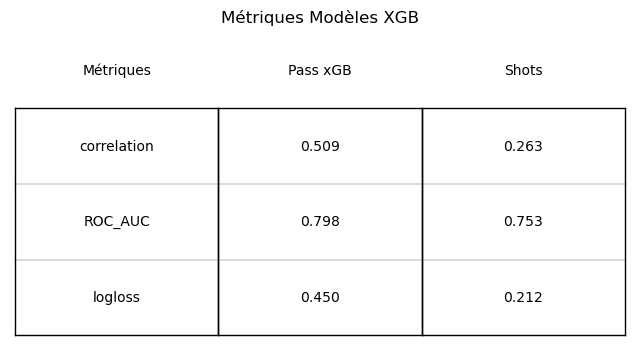

In [19]:
# creation du df pour le tableau
df_df = {
    "passxgb": {"correlation": corr_pass, "ROC_AUC": auc_pass, "logloss": logloss_pass},
    "shots": {"correlation": corr_shot, "ROC_AUC": auc_shot, "logloss": logloss_shot},
}
df_df = pd.DataFrame(df_df)

fig, ax = plt.subplots(figsize=(8, 4))
Table(
    df_df,
    ax=ax,
    column_definitions=[
        ColDef(
            name="index", title="Métriques", border="both", textprops={"ha": "center"}
        ),
        ColDef(
            name="passxgb",
            title="Pass xGB",
            border="both",
            formatter="{:.3f}",
            textprops={"ha": "center"},
        ),
        ColDef(
            name="shots",
            title="Shots",
            border="both",
            formatter="{:.3f}",
            textprops={"ha": "center"},
        ),
    ],
    footer_divider=True,
)

plt.title("Métriques Modèles XGB")
plt.show()

In [20]:
# pour merge avec les jes stints pour leurs position
player = Players_raw.copy()


stints_1 = Stints_raw.merge(
    player[["primary_position", "player_id"]], on="player_id", how="left"
)

# on enleve les gardiens
stints_1 = stints_1[stints_1["primary_position"] != "G"]

# On met tout les joueurs du meme stint et de la meme équipe ensemble
lineups = (
    stints_1.groupby(["game_id", "game_stint", "team_id"])["player_id"]
    .apply(lambda x: tuple(sorted(x)))
    .reset_index(name="joueur_stint")
)

# On fait un real stint id pour différencier les stints déquipe
lineups["real_stint_id"] = lineups.groupby("joueur_stint").ngroup()
# on détermine la longueur
lineups["n_player"] = lineups["joueur_stint"].apply(len)

# On fait un gros df avec tout les stints et leurs real_stint_id
stints_test = stints_1.merge(
    lineups[["game_id", "game_stint", "team_id", "real_stint_id", "n_player"]],
    on=["game_id", "game_stint", "team_id"],
    how="left",
)

In [21]:
# On fait un nouveau df des stints en mergeant le real stint id avec toutes les passes
OZ_passes_pn = OZ_passes_PAV.copy()
print(f"grosseur avant: {len(OZ_passes_pn)}")

OZ_passes_pn = OZ_passes_pn.merge(
    stints_test[["game_id", "game_stint", "team_id", "real_stint_id", "n_player"]],
    on=["game_id", "game_stint", "team_id"],
    how="left",
)

OZ_passes_pn = OZ_passes_pn.drop_duplicates()

print(f"grosseur apres: {len(OZ_passes_pn)}")

grosseur avant: 119485
grosseur apres: 119485


In [22]:
# compter le nombre de passes par duo passeur-receveur
pass_count = (
    OZ_passes_pn.groupby(["player_id", "joueur_rec_id"])
    .agg(n_passes=("real_event_id", "count"))
    .reset_index()
)

# sommer le PAV par duo passeur-receveur
pav_sum = (
    OZ_passes_pn.groupby(["player_id", "joueur_rec_id"])
    .agg(n_pav=("PAV", "sum"))
    .reset_index()
)

# calculer les coordonnées moyennes de début et de fin de passe par duo pour l'illustration
pass_count_x = (
    OZ_passes_pn.groupby(["player_id", "joueur_rec_id"])
    .agg(x=("x_adj", "mean"))
    .reset_index()
)
pass_count = pass_count.merge(
    pass_count_x, on=["player_id", "joueur_rec_id"], how="left"
)
pass_count_y = (
    OZ_passes_pn.groupby(["player_id", "joueur_rec_id"])
    .agg(y=("y_adj", "mean"))
    .reset_index()
)
pass_count = pass_count.merge(
    pass_count_y, on=["player_id", "joueur_rec_id"], how="left"
)
pass_count_x_fin = (
    OZ_passes_pn.groupby(["player_id", "joueur_rec_id"])
    .agg(x_fin=("x_fin_adj", "mean"))
    .reset_index()
)
pass_count = pass_count.merge(
    pass_count_x_fin, on=["player_id", "joueur_rec_id"], how="left"
)
pass_count_y_fin = (
    OZ_passes_pn.groupby(["player_id", "joueur_rec_id"])
    .agg(y_fin=("y_fin_adj", "mean"))
    .reset_index()
)
pass_count = pass_count.merge(
    pass_count_y_fin, on=["player_id", "joueur_rec_id"], how="left"
)

# meme logique pour pav_sum: coordonnées moyennes de début et de fin de passe par duo
pav_sum_x = (
    OZ_passes_pn.groupby(["player_id", "joueur_rec_id"])
    .agg(x=("x_adj", "mean"))
    .reset_index()
)
pav_sum = pav_sum.merge(pav_sum_x, on=["player_id", "joueur_rec_id"], how="left")
pav_sum_y = (
    OZ_passes_pn.groupby(["player_id", "joueur_rec_id"])
    .agg(y=("y_adj", "mean"))
    .reset_index()
)
pav_sum = pav_sum.merge(pav_sum_y, on=["player_id", "joueur_rec_id"], how="left")
pav_sum_x_fin = (
    OZ_passes_pn.groupby(["player_id", "joueur_rec_id"])
    .agg(x_fin=("x_fin_adj", "mean"))
    .reset_index()
)
pav_sum = pav_sum.merge(pav_sum_x_fin, on=["player_id", "joueur_rec_id"], how="left")
pav_sum_y_fin = (
    OZ_passes_pn.groupby(["player_id", "joueur_rec_id"])
    .agg(y_fin=("y_fin_adj", "mean"))
    .reset_index()
)
pav_sum = pav_sum.merge(pav_sum_y_fin, on=["player_id", "joueur_rec_id"], how="left")

In [23]:
# sum le PAV total généré par chaque passeur (impact offensif en tant que passeur)
out_degree = pav_sum.groupby("player_id").agg(out_degree=("n_pav", "sum")).reset_index()

# sum le PAV total reçu par chaque receveur (impact offensif en tant que receveur)
in_degree = (
    pav_sum.groupby("joueur_rec_id").agg(in_degree=("n_pav", "sum")).reset_index()
)

# renommer pour pouvoir merger sur le même player_id
in_degree = in_degree.rename(columns={"joueur_rec_id": "player_id"})

# merger les deux pour avoir l'impact total de chaque joueur outer pour garder tous les joueurs
player_impact = out_degree.merge(in_degree, on="player_id", how="outer").fillna(0)

# impact total = PAV généré + PAV reçu
player_impact["total_involvement"] = (
    player_impact["in_degree"] + player_impact["out_degree"]
)

# trier par impact total pour voir les joueurs les plus importants en premier
player_impact = player_impact.sort_values("total_involvement", ascending=False)

In [24]:
stints = Stints_raw.copy()

# durée de chaque stint en secondes
stints["stints_duration"] = stints["period_time_end"] - stints["period_time_start"]

# toi total par joueur
toi = stints.groupby("player_id").agg(toi_sec=("stints_duration", "sum")).reset_index()

# convertir en minutes
toi["toi_sec"] = toi["toi_sec"].astype(float)
toi["toi_minutes"] = toi["toi_sec"] / 60.0

# ajouter le nom des joueurs
player_impact_wn = player_impact.merge(
    Players_raw[["player_id", "player_name"]], on="player_id"
)

# merger le toi
player_impact_wtoi = player_impact_wn.merge(
    toi[["player_id", "toi_minutes"]], on="player_id", how="left"
)

# enlever les joueurs sans toi
player_impact_wtoi = player_impact_wtoi[
    (player_impact_wtoi["toi_minutes"].notna())
    & (player_impact_wtoi["toi_minutes"] > 0)
]

# normaliser par 60 minutes ou 1 matchs complet
player_impact_wtoi["out_per60"] = (
    player_impact_wtoi["out_degree"] / player_impact_wtoi["toi_minutes"] * 60
)
player_impact_wtoi["in_per60"] = (
    player_impact_wtoi["in_degree"] / player_impact_wtoi["toi_minutes"] * 60
)
player_impact_wtoi["parttot_per60"] = (
    player_impact_wtoi["total_involvement"] / player_impact_wtoi["toi_minutes"] * 60
)

In [25]:
eig_list = []

# trouver l'équipe de chaque joueur
joueur_équipe = Events_raw[["player_id", "team_id"]].drop_duplicates("player_id")

# ajouter l'équipe au df de pav pour grouper par équipe
pav_sum_1 = pav_sum.merge(joueur_équipe[["player_id", "team_id"]], on="player_id")

for team, df_team in pav_sum_1.groupby("team_id"):

    # créer un graphe dirigé par équipe avec le PAV comme poids des edges
    G_team = nx.from_pandas_edgelist(
        df_team,
        source="player_id",
        target="joueur_rec_id",
        edge_attr="n_pav",
        create_using=nx.DiGraph(),
    )

    # calculer la centralité eigenvector pour chaque joueur dans le graphe de l'équipe
    eig_team = nx.eigenvector_centrality(G_team, weight="weight", max_iter=200)

    # ajouter les résultats à la liste
    eig_list.extend(
        [
            {"player_id": key, "team_id": team, "eig": value}
            for key, value in eig_team.items()
        ]
    )

# convertir en df
eig_pav_df = pd.DataFrame(eig_list)

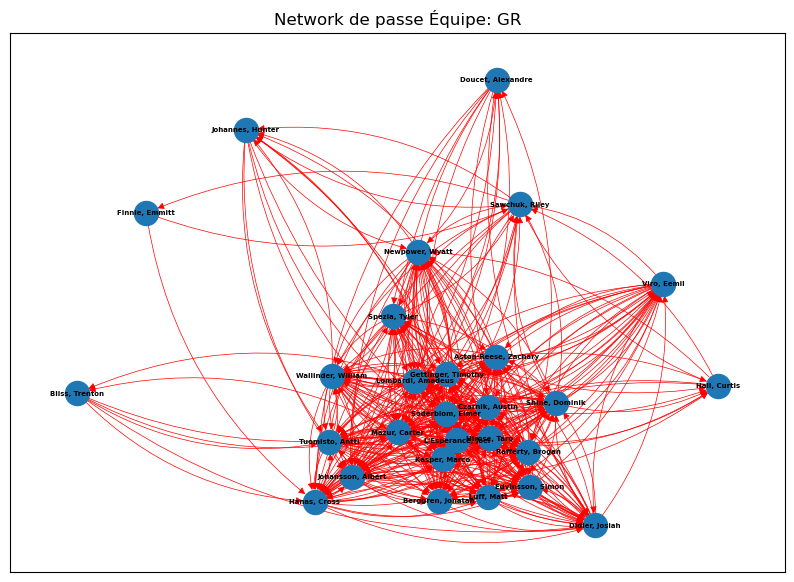

In [26]:
pass_sum_graph = pav_sum.copy()

# lookup pour trouver l'équipe de chaque joueur
team_lookup = Events_raw[["player_id", "team"]].drop_duplicates()

# ajouter le nom du passeur et du receveur
pass_sum_graph = pass_sum_graph.merge(
    Players_raw[["player_id", "player_name"]], on="player_id"
).rename(columns={"player_name": "passer_name"})
pass_sum_graph = (
    pass_sum_graph.merge(
        Players_raw[["player_id", "player_name"]],
        left_on="joueur_rec_id",
        right_on="player_id",
    )
    .rename(columns={"player_name": "receiver_name"})
    .drop(columns="player_id_y")
    .rename(columns={"player_id_x": "player_id"})
)

# ajouter l'équipe du passeur et du receveur
pass_sum_graph = pass_sum_graph.merge(
    team_lookup[["team", "player_id"]], on="player_id"
).rename(columns={"team": "passer_team"})
pass_sum_graph = (
    pass_sum_graph.merge(
        team_lookup[["team", "player_id"]],
        left_on="joueur_rec_id",
        right_on="player_id",
    )
    .rename(columns={"team": "receiver_team"})
    .drop(columns="player_id_y")
    .rename(columns={"player_id_x": "player_id"})
)

# enlever les doublons en ignorant les colonnes d'équipe
colonnes_delete = pass_sum_graph.columns.difference(["passer_team", "receiver_team"])
pass_sum_graph = pass_sum_graph.drop_duplicates(subset=colonnes_delete)

# enlever les passes à soi-même
pass_sum_graph = pass_sum_graph[
    pass_sum_graph["passer_name"] != pass_sum_graph["receiver_name"]
]

# filtrer pour une équipe spécifique
team = "GR"
team_passes = pass_sum_graph[
    (pass_sum_graph["passer_team"] == team) & (pass_sum_graph["receiver_team"] == team)
]
team_passes = team_passes.drop_duplicates()

# créer le graphe dirigé avec le PAV comme poids
G_team = nx.DiGraph()

for df, row in team_passes.iterrows():
    G_team.add_edge(row["passer_name"], row["receiver_name"], weight=row["n_pav"])

# positionner les noeuds avec spring layout
localisation = nx.spring_layout(G_team, seed=82, k=0.5)

# illustrer le graphe
graph, axe = plt.subplots(figsize=(10, 7))
nx.draw_networkx(
    G_team,
    localisation,
    ax=axe,
    font_size=5,
    width=0.5,
    font_weight="bold",
    edge_color="red",
    arrows=True,
    arrowsize=10,
    connectionstyle="arc3,rad=0.2",
)

plt.title(f"Network de passe Équipe: {team}")
plt.show()

In [27]:
player_impact_pr_pos = player_impact_wtoi.copy()

# garder seulement les passes avec PAV positif
pr_pos_temp = pav_sum[pav_sum["n_pav"] >= 0]

# créer le graphe dirigé avec seulemnt les passes positives
G_pr_pos = nx.DiGraph()

for df, row in pr_pos_temp.iterrows():
    G_pr_pos.add_edge(row["player_id"], row["joueur_rec_id"], weight=row["n_pav"])

# calculer le pagerank positif
pr_pos = nx.pagerank(G_pr_pos, weight="weight")

# convertir en df
pr_pos_df = pd.Series(pr_pos, name="pr_pos").reset_index()
pr_pos_df = pr_pos_df.rename(columns={"index": "player_id"})

player_impact_pr_neg = player_impact_wtoi.copy()

# garder seuelemnt les passes avec PAV négatif
pr_neg_temp = pav_sum[pav_sum["n_pav"] < 0]

# créer le graphe dirigé avec seulement les passes négatives
G_pr_neg = nx.DiGraph()

for df, row in pr_neg_temp.iterrows():
    G_pr_neg.add_edge(row["player_id"], row["joueur_rec_id"], weight=row["n_pav"])

# calculer le pagerank négatif
pr_neg = nx.pagerank(G_pr_neg, weight="weight")

# convertir en df
pr_neg_df = pd.Series(pr_neg, name="pr_neg").reset_index()
pr_neg_df = pr_neg_df.rename(columns={"index": "player_id"})

# merger les deux pageranks et calculer le pagerank net en z-score
pr_full = pr_pos_df.merge(pr_neg_df, on="player_id")
pr_full["pr_net"] = zscore(pr_full["pr_pos"] - pr_full["pr_neg"])

# merger avec le main df
player_impact_wpr = player_impact_wtoi.merge(pr_full, on="player_id")

In [28]:
# trouver le team_id de chaque équipe pour merger avec les passes
team_ids = (
    Games_raw[["home_team", "home_team_id"]]
    .drop_duplicates()
    .rename(columns=({"home_team": "team", "home_team_id": "team_id"}))
)
team_lookup_1 = team_lookup.merge(team_ids, on="team")

# renommer pour le merge sur le receveur
team_lookup_rec = team_lookup_1.rename(
    columns={"player_id": "joueur_rec_id", "team_id": "team_rec_id"}
)

# ajouter l'équipe du receveur et garder seulemnt les passes intra-équipe
OZ_passes_pn_1 = OZ_passes_pn.merge(team_lookup_rec, on="joueur_rec_id")
OZ_passes_pn_1 = OZ_passes_pn_1[
    OZ_passes_pn_1["team_id"] == OZ_passes_pn_1["team_rec_id"]
]

# compter le nombre de passes par stint
stint_counts = OZ_passes_pn_1["real_stint_id"].value_counts()

# trouver le nombre de joueurs uniques par stint
player_id_pass = OZ_passes_pn_1[["real_stint_id", "player_id"]]
player_id_rec = OZ_passes_pn_1[["real_stint_id", "joueur_rec_id"]].rename(
    columns={"joueur_rec_id": "player_id"}
)
players_per_stint = (
    pd.concat([player_id_pass, player_id_rec])
    .groupby("real_stint_id")["player_id"]
    .nunique()
)

# garder seulemnt les stints avec assez de passes et entre 4 et 6 joueurs
valid_stints = stint_counts[
    (stint_counts >= 5) & ((players_per_stint >= 4) & (players_per_stint <= 6))
].index
passes_filtered = OZ_passes_pn_1[OZ_passes_pn_1["real_stint_id"].isin(valid_stints)]

bet_list = []

for stint_id, df_stint in passes_filtered.groupby("real_stint_id"):
    # sommer le PAV par duo passeur-receveur dans le stint
    df = df_stint.groupby(["player_id", "joueur_rec_id"])["PAV"].sum()
    df = df.reset_index(name="poid")
    # Normalizer les poids pour qu'ils soient tous positifs car betweenness accepte pas les poids négatifs
    df["poid"] = df["poid"] - df["poid"].min() + 0.00000000001
    # créer le graphe dirigé du stint
    G_bet = nx.from_pandas_edgelist(
        df,
        source="player_id",
        target="joueur_rec_id",
        edge_attr="poid",
        create_using=nx.DiGraph(),
    )
    # calculer la betweenness centrality pour chaque joueur dans le stint
    bet = nx.betweenness_centrality(G_bet, weight="poid", normalized=True)
    # ajouter les résultats à la liste
    bet_list.extend(
        [
            {"player_id": key, "real_stint_id": stint_id, "bet": value}
            for key, value in bet.items()
        ]
    )

bet_df = pd.DataFrame(bet_list)

# merger le nombre de passes par stint pour pondérer la betweenness
bet_df = bet_df.merge(stint_counts, on="real_stint_id", how="left")

# calculer la betweenness pondérée par le nombre de passes du stint
weighted_bet_df = (
    bet_df.groupby("player_id")
    .apply(lambda wbet: ((wbet["bet"] * wbet["count"]).sum()) / (wbet["count"].sum()))
    .reset_index()
)
weighted_bet_df = weighted_bet_df.rename(columns={0: "wbet"})

C:\Users\gabri\AppData\Local\Temp\ipykernel_29452\1448814621.py:74: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda wbet: ((wbet["bet"] * wbet["count"]).sum()) / (wbet["count"].sum()))


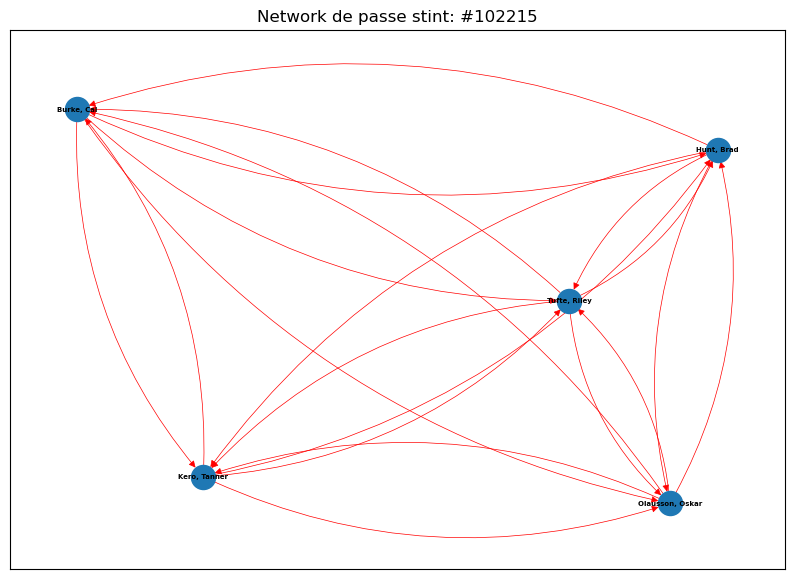

In [29]:
pass_filt = passes_filtered.copy()

# ajouter le nom du receveur
player_rec_temp = Players_raw[["player_id", "player_name"]].rename(
    columns={"player_name": "receiver_name", "player_id": "joueur_rec_id"}
)
pass_filt = pass_filt.merge(player_rec_temp, on="joueur_rec_id")

# ajouter l'équipe du passeur et du receveur
pass_filt = pass_filt.merge(team_lookup[["team", "player_id"]], on="player_id").rename(
    columns={"team": "passer_team"}
)
pass_filt = (
    pass_filt.merge(
        team_lookup[["team", "player_id"]],
        left_on="joueur_rec_id",
        right_on="player_id",
    )
    .rename(columns={"team": "receiver_team"})
    .drop(columns="player_id_y")
    .rename(columns={"player_id_x": "player_id"})
)

# enlever les doublons en ignorant les colonnes d'équipe
colonnes_delete = pass_filt.columns.difference(["passer_team", "receiver_team"])
pass_filt = pass_filt.drop_duplicates(subset=colonnes_delete)

# enlever les passes à soi-meme
pass_filt = pass_filt[pass_filt["player_name"] != pass_filt["receiver_name"]]

# changer ici pour illustrer un stint différent
stint_choice = 102215
stint_df = pass_filt[pass_filt["real_stint_id"] == stint_choice]

# créer le graphe dirigé du stint avec le PAV comme poids
G_stint = nx.DiGraph()

for df, row in stint_df.iterrows():
    G_stint.add_edge(row["player_name"], row["receiver_name"], weight=row["PAV"])

# positionner les noeuds avec spring layout
localisation = nx.spring_layout(G_stint, seed=15, k=0.5)

# illustrer le graphe
graph, axe = plt.subplots(figsize=(10, 7))
nx.draw_networkx(
    G_stint,
    localisation,
    ax=axe,
    font_size=5,
    width=0.5,
    font_weight="bold",
    edge_color="red",
    arrows=True,
    arrowsize=10,
    connectionstyle="arc3,rad=0.2",
)

plt.title(f"Network de passe stint: #{stint_choice}")
plt.show()

In [30]:
# merger le P% de chaque passe
passxgb_merge = passxgb[["real_event_id", "P%"]]
OZ_passes_PAV_1 = OZ_passes_PAV.merge(passxgb_merge, on="real_event_id", how="left")

# merger toutes les métriques de graph dans le main df
player_impact_df = player_impact_wpr.copy()
player_impact_df = player_impact_df.merge(weighted_bet_df, on="player_id")
player_impact_df = player_impact_df.merge(eig_pav_df, on="player_id")

# P% moyen des passes faites par chaque joueur
passrisk_out = (
    OZ_passes_PAV_1.groupby("player_id").agg(in_p=("P%", "mean")).reset_index()
)
passrisk_out = passrisk_out[["player_id", "in_p"]]
player_impact_df = player_impact_df.merge(passrisk_out, on="player_id")

# P% moyen des passes recues par chaque joueur
passrisk_in = (
    OZ_passes_PAV_1.groupby("joueur_rec_id").agg(out_p=("P%", "mean")).reset_index()
)
passrisk_in = passrisk_in[["joueur_rec_id", "out_p"]]
passrisk_in = passrisk_in.rename(columns={"joueur_rec_id": "player_id"})
player_impact_df = player_impact_df.merge(passrisk_in, on="player_id")

# enlever les doublons
player_impact_df = player_impact_df.drop_duplicates()

# garder seulemnt les joueurs ayant joué plus de 100 minutes
player_impact_df = player_impact_df[player_impact_df["toi_minutes"] >= 100]

# ajouter les équipes et les positions
Players_merge = Players_raw[["player_id", "primary_position"]]
player_impact_df = player_impact_df.merge(Players_merge, on="player_id")
player_impact_df = player_impact_df.merge(
    team_lookup_1[["player_id", "team"]], on="player_id"
)

# enlever les doublons de joueurs
player_impact_df = player_impact_df.drop_duplicates(subset=["player_name"])

# calcul de la métrique finale avec ses poids
player_impact_df["IOHR"] = (
    5 * player_impact_df["in_p"] * player_impact_df["in_per60"]
    + 20 * player_impact_df["wbet"]
    + 10 * player_impact_df["eig"]
    + 1 * player_impact_df["pr_net"]
)

player_impact_df.iloc[0:1].style.hide("player_id", axis="columns")

,out_degree,in_degree,total_involvement,player_name,toi_minutes,out_per60,in_per60,parttot_per60,pr_pos,pr_neg,pr_net,wbet,team_id,eig,in_p,out_p,primary_position,team,IOHR
0,5.783947,3.068789,8.852736,"Bourque, Mavrik",592.460167,0.585755,0.310784,0.896540,0.003071,0.000754,1.657464,0.263062,9bfe142b-8c31-828f-dde8-a252d75d5ef3,0.225894,0.804227,0.779589,C,TEX,10.427345


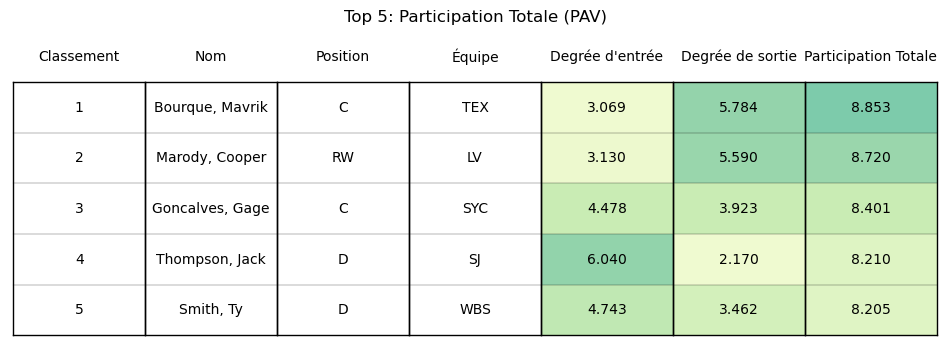

In [31]:
# Pour les prochaines cellules ce sont relativement les étapes donc je vais écrire les détails ici pour pas avoir à tout les réécrire

# On sort par la métrique voulu
player_impact_df = player_impact_df.sort_values("total_involvement", ascending=False)

# On garde seulement les colonnes pertinante
player_impact_df_table = player_impact_df[
    [
        "player_name",
        "primary_position",
        "team",
        "in_degree",
        "out_degree",
        "total_involvement",
    ]
].head(5)
player_impact_df_table.iloc[0:5]

# On reset l'index pour faire un classement de 1 - 5
player_impact_df_table = player_impact_df_table.reset_index(drop=True)
player_impact_df_table.index += 1

# De l'exemple de la library plottable https://plottable.readthedocs.io/en/latest/example_notebooks/wwc_example.html
cmap = LinearSegmentedColormap.from_list(
    name="bugw", colors=["#ffffff", "#f2fbd2", "#c9ecb4", "#93d3ab", "#35b0ab"], N=256
)


fig, ax = plt.subplots(figsize=(12, 4))

Table(
    player_impact_df_table,
    ax=ax,
    column_definitions=[
        ColDef(
            name="index", title="Classement", border="both", textprops={"ha": "center"}
        ),
        ColDef(
            name="player_name", title="Nom", border="both", textprops={"ha": "center"}
        ),
        ColDef(
            name="primary_position",
            title="Position",
            border="both",  # border partout autour
            textprops={"ha": "center"},  # pour que le texte soit centrée
        ),
        ColDef(name="team", title="Équipe", border="both", textprops={"ha": "center"}),
        ColDef(
            name="in_degree",
            title="Degrée d'entrée",
            border="both",
            formatter="{:^.3f}",  # 3 décimale apres la ,
            textprops={"ha": "center"},  # centrée
            cmap=normed_cmap(
                player_impact_df_table["in_degree"],
                cmap=cmap,
                num_stds=2.5,  # pour que les couleurs soit graduelles
            ),
        ),
        ColDef(
            name="out_degree",
            title="Degrée de sortie",
            border="both",
            formatter="{:^.3f}",
            textprops={"ha": "center"},
            cmap=normed_cmap(
                player_impact_df_table["out_degree"], cmap=cmap, num_stds=2.5
            ),
        ),
        ColDef(
            name="total_involvement",
            title="Participation Totale",
            border="both",
            formatter="{:^.3f}",
            textprops={"ha": "center"},
            cmap=normed_cmap(
                player_impact_df_table["total_involvement"], cmap=cmap, num_stds=2.5
            ),
        ),
    ],
    footer_divider=True,
)
plt.title("Top 5: Participation Totale (PAV)")
plt.show()

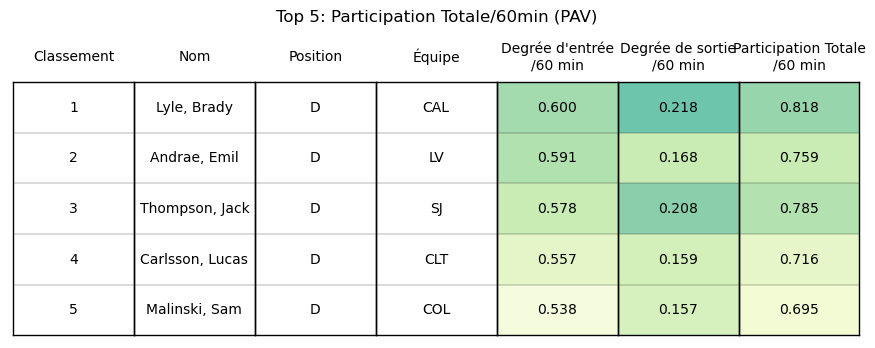

In [32]:
#MEME LOGIQUE QUE LA CELLULE AVANT
player_impact_df = player_impact_df.sort_values("in_per60", ascending=False)
player_impact_df_table = player_impact_df[
    [
        "player_name",
        "primary_position",
        "team",
        "in_per60",
        "out_per60",
        "parttot_per60",
    ]
].head(5)
player_impact_df_table.iloc[0:5]
player_impact_df_table = player_impact_df_table.reset_index(drop=True)
player_impact_df_table.index += 1

# De l'exemple de la library plottable https://plottable.readthedocs.io/en/latest/example_notebooks/wwc_example.html
cmap = LinearSegmentedColormap.from_list(
    name="bugw", colors=["#ffffff", "#f2fbd2", "#c9ecb4", "#93d3ab", "#35b0ab"], N=256
)


fig, ax = plt.subplots(figsize=(11, 4))
Table(
    player_impact_df_table,
    ax=ax,
    column_definitions=[
        ColDef(
            name="index", title="Classement", border="both", textprops={"ha": "center"}
        ),
        ColDef(
            name="player_name", title="Nom", border="both", textprops={"ha": "center"}
        ),
        ColDef(
            name="primary_position",
            title="Position",
            border="both",
            textprops={"ha": "center"},
        ),
        ColDef(name="team", title="Équipe", border="both", textprops={"ha": "center"}),
        ColDef(
            name="in_per60",
            title="Degrée d'entrée\n/60 min",
            border="both",
            formatter="{:^.3f}",
            textprops={"ha": "center"},
            cmap=normed_cmap(
                player_impact_df_table["in_per60"], cmap=cmap, num_stds=2.5
            ),
        ),
        ColDef(
            name="out_per60",
            title="Degrée de sortie\n/60 min",
            border="both",
            formatter="{:^.3f}",
            textprops={"ha": "center"},
            cmap=normed_cmap(
                player_impact_df_table["out_per60"], cmap=cmap, num_stds=2.5
            ),
        ),
        ColDef(
            name="parttot_per60",
            title="Participation Totale\n/60 min",
            border="both",
            formatter="{:^.3f}",
            textprops={"ha": "center"},
            cmap=normed_cmap(
                player_impact_df_table["parttot_per60"], cmap=cmap, num_stds=2.5
            ),
        ),
    ],
    footer_divider=True,
)
plt.title("Top 5: Participation Totale/60min (PAV)")
plt.show()

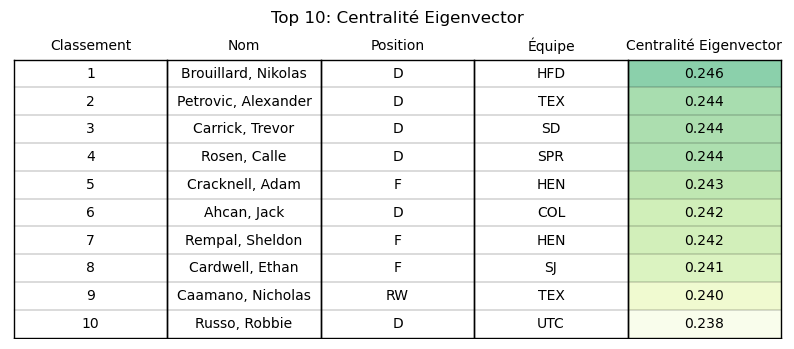

In [33]:
#MEME LOGIQUE QUE LA CELLULE AVANT
player_impact_df = player_impact_df.sort_values("eig", ascending=False)
player_impact_df_table = player_impact_df[
    ["player_name", "primary_position", "team", "eig"]
].head(10)
player_impact_df_table.iloc[0:5]
player_impact_df_table = player_impact_df_table.reset_index(drop=True)
player_impact_df_table.index += 1

# De l'exemple de la library plottable https://plottable.readthedocs.io/en/latest/example_notebooks/wwc_example.html
cmap = LinearSegmentedColormap.from_list(
    name="bugw", colors=["#ffffff", "#f2fbd2", "#c9ecb4", "#93d3ab", "#35b0ab"], N=256
)

fig, ax = plt.subplots(figsize=(10, 4))
Table(
    player_impact_df_table,
    ax=ax,
    column_definitions=[
        ColDef(
            name="index", title="Classement", border="both", textprops={"ha": "center"}
        ),
        ColDef(
            name="player_name", title="Nom", border="both", textprops={"ha": "center"}
        ),
        ColDef(
            name="primary_position",
            title="Position",
            border="both",
            textprops={"ha": "center"},
        ),
        ColDef(name="team", title="Équipe", border="both", textprops={"ha": "center"}),
        ColDef(
            name="eig",
            title="Centralité Eigenvector",
            border="both",
            formatter="{:^.3f}",
            textprops={"ha": "center"},
            cmap=normed_cmap(player_impact_df_table["eig"], cmap=cmap, num_stds=2.5),
        ),
    ],
    footer_divider=True,
)
plt.title("Top 10: Centralité Eigenvector")
plt.show()

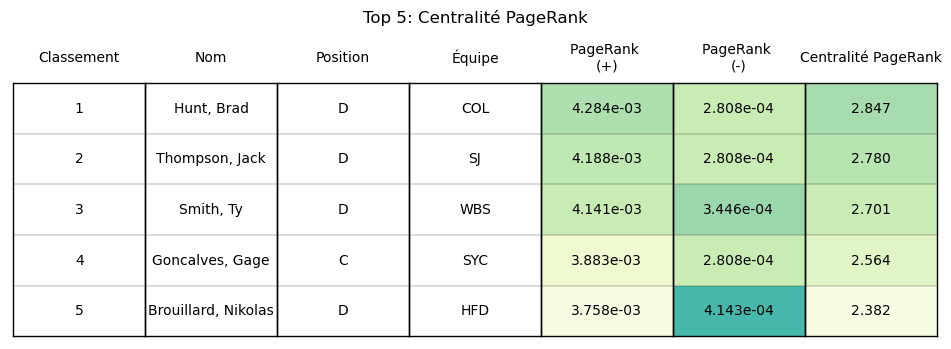

In [34]:
#MEME LOGIQUE QUE LA CELLULE AVANT
player_impact_df_table = player_impact_df.sort_values("pr_net", ascending=False)
player_impact_df_table = player_impact_df_table[
    ["player_name", "primary_position", "team", "pr_pos", "pr_neg", "pr_net"]
].head(5)
player_impact_df_table.iloc[0:5]
player_impact_df_table = player_impact_df_table.reset_index(drop=True)
player_impact_df_table.index += 1

# De l'exemple de la library plottable https://plottable.readthedocs.io/en/latest/example_notebooks/wwc_example.html
cmap = LinearSegmentedColormap.from_list(
    name="bugw", colors=["#ffffff", "#f2fbd2", "#c9ecb4", "#93d3ab", "#35b0ab"], N=256
)

fig, ax = plt.subplots(figsize=(12, 4))
Table(
    player_impact_df_table,
    ax=ax,
    column_definitions=[
        ColDef(
            name="index", title="Classement", border="both", textprops={"ha": "center"}
        ),
        ColDef(
            name="player_name", title="Nom", border="both", textprops={"ha": "center"}
        ),
        ColDef(
            name="primary_position",
            title="Position",
            border="both",
            textprops={"ha": "center"},
        ),
        ColDef(name="team", title="Équipe", border="both", textprops={"ha": "center"}),
        ColDef(
            name="pr_pos",
            title="PageRank \n(+)",
            border="both",
            formatter="{:^.3e}",
            textprops={"ha": "center"},
            cmap=normed_cmap(player_impact_df_table["pr_pos"], cmap=cmap, num_stds=2.5),
        ),
        ColDef(
            name="pr_neg",
            title="PageRank \n(-)",
            border="both",
            formatter="{:^.3e}",
            textprops={"ha": "center"},
            cmap=normed_cmap(player_impact_df_table["pr_neg"], cmap=cmap, num_stds=2.5),
        ),
        ColDef(
            name="pr_net",
            title="Centralité PageRank",
            border="both",
            formatter="{:^.3f}",
            textprops={"ha": "center"},
            cmap=normed_cmap(player_impact_df_table["pr_net"], cmap=cmap, num_stds=2.5),
        ),
    ],
    footer_divider=True,
)
plt.title("Top 5: Centralité PageRank")
plt.show()

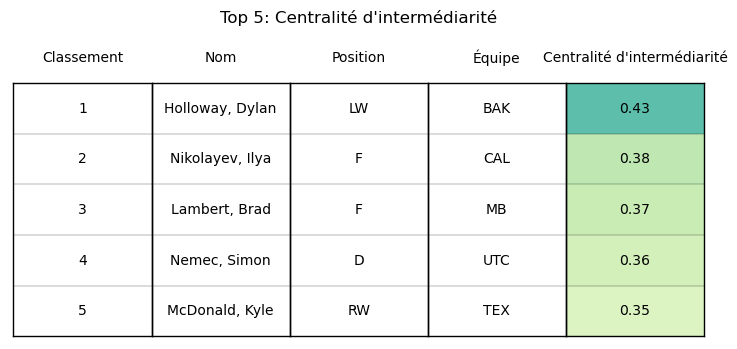

In [35]:
#MEME LOGIQUE QUE LA CELLULE AVANT
player_impact_df_table = player_impact_df.sort_values("wbet", ascending=False)
player_impact_df_table = player_impact_df_table[
    ["player_name", "primary_position", "team", "wbet"]
].head(5)
player_impact_df_table.iloc[0:5]
player_impact_df_table = player_impact_df_table.reset_index(drop=True)
player_impact_df_table.index += 1

# De l'exemple de la library plottable https://plottable.readthedocs.io/en/latest/example_notebooks/wwc_example.html
cmap = LinearSegmentedColormap.from_list(
    name="bugw", colors=["#ffffff", "#f2fbd2", "#c9ecb4", "#93d3ab", "#35b0ab"], N=256
)

fig, ax = plt.subplots(figsize=(9, 4))
Table(
    player_impact_df_table,
    ax=ax,
    column_definitions=[
        ColDef(
            name="index", title="Classement", border="both", textprops={"ha": "center"}
        ),
        ColDef(
            name="player_name", title="Nom", border="both", textprops={"ha": "center"}
        ),
        ColDef(
            name="primary_position",
            title="Position",
            border="both",
            textprops={"ha": "center"},
        ),
        ColDef(name="team", title="Équipe", border="both", textprops={"ha": "center"}),
        ColDef(
            name="wbet",
            title="Centralité d'intermédiarité",
            border="both",
            formatter="{:^.2f}",
            textprops={"ha": "center"},
            cmap=normed_cmap(player_impact_df_table["wbet"], cmap=cmap, num_stds=2.5),
        ),
    ],
    footer_divider=True,
)
plt.title("Top 5: Centralité d'intermédiarité")
plt.show()

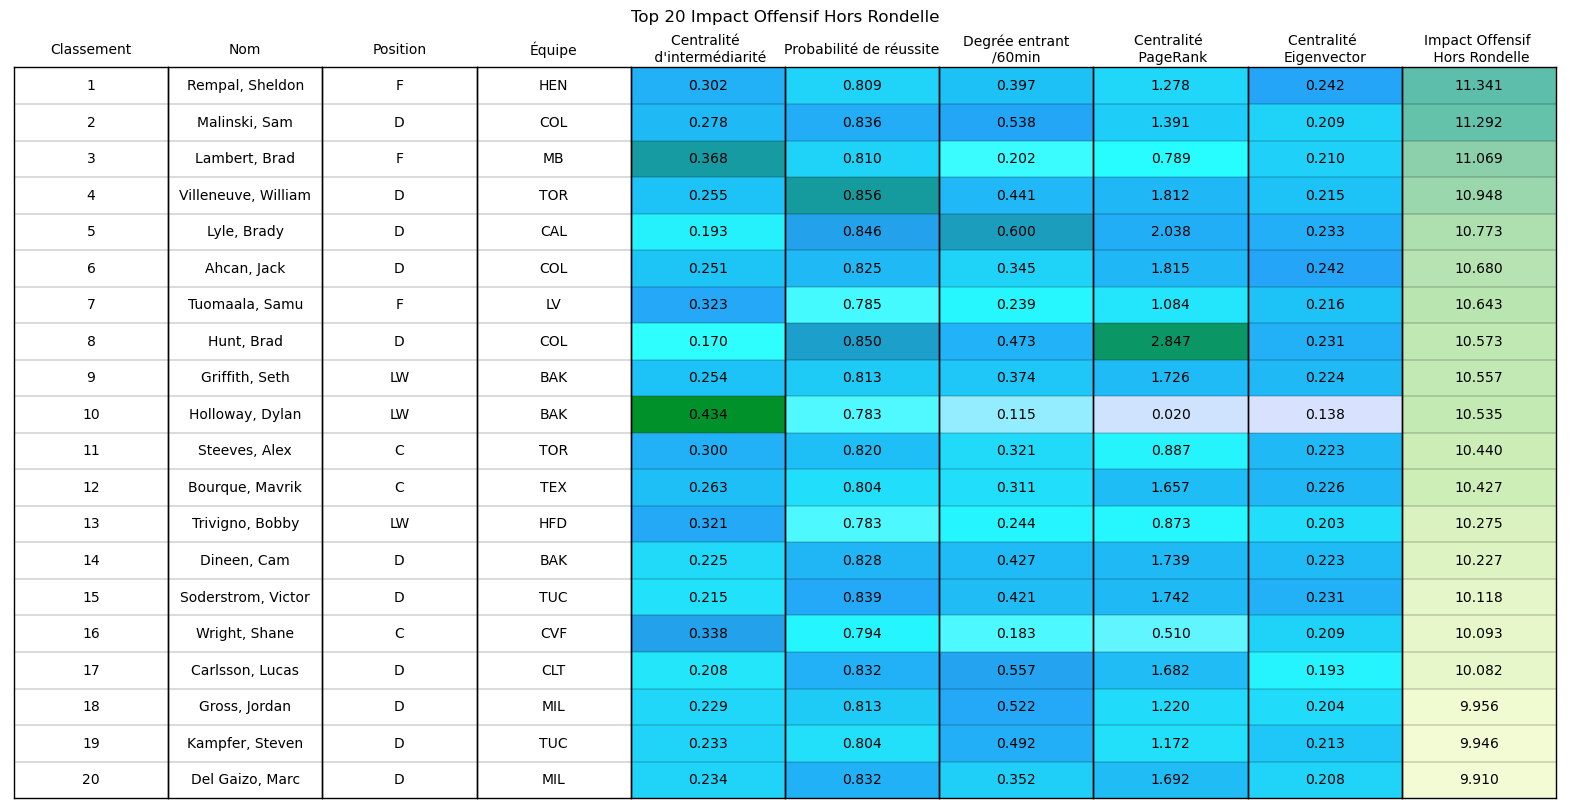

In [36]:
#MEME LOGIQUE QUE LA CELLULE AVANT
player_impact_df = player_impact_df.sort_values("IOHR", ascending=False)
player_impact_df_table = player_impact_df[
    [
        "player_name",
        "primary_position",
        "team",
        "wbet",
        "in_p",
        "in_per60",
        "pr_net",
        "eig",
        "IOHR",
    ]
].head(20)
player_impact_df_table.iloc[0:5]
player_impact_df_table = player_impact_df_table.reset_index(drop=True)
player_impact_df_table.index += 1

# De l'exemple de la library plottable https://plottable.readthedocs.io/en/latest/example_notebooks/wwc_example.html
cmap = LinearSegmentedColormap.from_list(
    name="bugw", colors=["#ffffff", "#f2fbd2", "#c9ecb4", "#93d3ab", "#35b0ab"], N=256
)
cmap_1 = LinearSegmentedColormap.from_list(
    name="bugw", colors=["#d8e2fe", "#27ffff", "#1dc3f6", "#25a3f7", "#00912b"], N=256
)
fig, ax = plt.subplots(figsize=(20, 10))
Table(
    player_impact_df_table,
    ax=ax,
    column_definitions=[
        ColDef(
            name="index", title="Classement", border="both", textprops={"ha": "center"}
        ),
        ColDef(
            name="player_name", title="Nom", border="both", textprops={"ha": "center"}
        ),
        ColDef(
            name="primary_position",
            title="Position",
            border="both",
            textprops={"ha": "center"},
        ),
        ColDef(name="team", title="Équipe", border="both", textprops={"ha": "center"}),
        ColDef(
            name="in_p",
            title="Probabilité de réussite",
            border="both",
            formatter="{:^.3f}",
            textprops={"ha": "center"},
            cmap=normed_cmap(player_impact_df_table["in_p"], cmap=cmap_1, num_stds=2.5),
        ),
        ColDef(
            name="in_per60",
            title="Degrée entrant\n/60min",
            border="both",
            formatter="{:^.3f}",
            textprops={"ha": "center"},
            cmap=normed_cmap(
                player_impact_df_table["in_per60"], cmap=cmap_1, num_stds=2.5
            ),
        ),
        ColDef(
            name="eig",
            title="Centralité \nEigenvector",
            border="both",
            formatter="{:^.3f}",
            textprops={"ha": "center"},
            cmap=normed_cmap(player_impact_df_table["eig"], cmap=cmap_1, num_stds=2.5),
        ),
        ColDef(
            name="wbet",
            title="Centralité \n d'intermédiarité",
            border="both",
            formatter="{:^.3f}",
            textprops={"ha": "center"},
            cmap=normed_cmap(player_impact_df_table["wbet"], cmap=cmap_1, num_stds=2.5),
        ),
        ColDef(
            name="pr_net",
            title="Centralité \n PageRank",
            border="both",
            formatter="{:^.3f}",
            textprops={"ha": "center"},
            cmap=normed_cmap(
                player_impact_df_table["pr_net"], cmap=cmap_1, num_stds=2.5
            ),
        ),
        ColDef(
            name="IOHR",
            title="Impact Offensif \n Hors Rondelle",
            border="both",
            formatter="{:^.3f}",
            textprops={"ha": "center"},
            cmap=normed_cmap(player_impact_df_table["IOHR"], cmap=cmap, num_stds=2.5),
        ),
    ],
    footer_divider=True,
)
plt.title("Top 20 Impact Offensif Hors Rondelle")
plt.show()

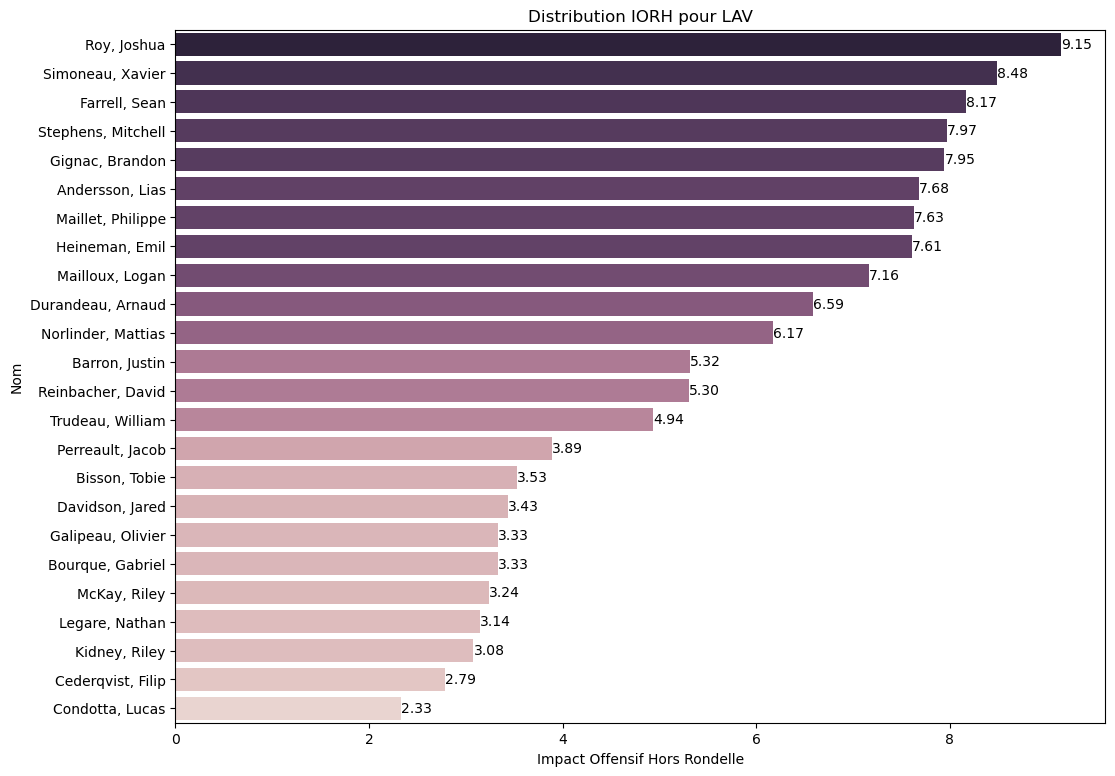

In [37]:
# changer ici pour illustrer une équipe différente
team_choice = "LAV"
player_impact_team = player_impact_df[player_impact_df["team"] == team_choice]

# barplot du IOHR par joueur pour l'équipe choisie
fig, ax = plt.subplots(figsize=(12, 9))
sns.barplot(
    data=player_impact_team, x="IOHR", y="player_name", hue="IOHR", legend=False, ax=ax
).set(
    title=f"Distribution IORH pour {team_choice}",
    xlabel="Impact Offensif Hors Rondelle",
    ylabel="Nom",
)

# ajouter les valeurs sur chaque barre
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=10)

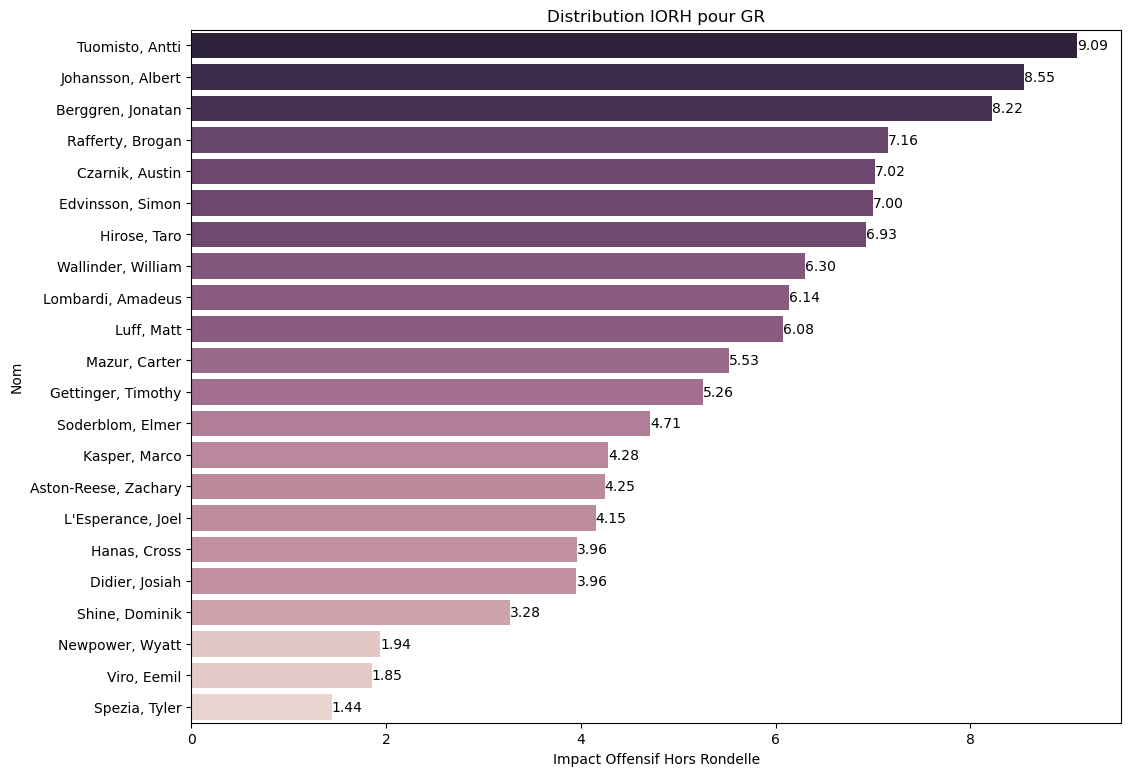

In [38]:
# changer ici pour illustrer une équipe différente
team_choice = "GR"
player_impact_team = player_impact_df[player_impact_df["team"] == team_choice]

# barplot du IOHR par joueur pour l'équipe choisie
fig, ax = plt.subplots(figsize=(12, 9))
sns.barplot(
    data=player_impact_team, x="IOHR", y="player_name", hue="IOHR", legend=False, ax=ax
).set(
    title=f"Distribution IORH pour {team_choice}",
    xlabel="Impact Offensif Hors Rondelle",
    ylabel="Nom",
)

# ajouter les valeurs sur chaque barre
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=10)

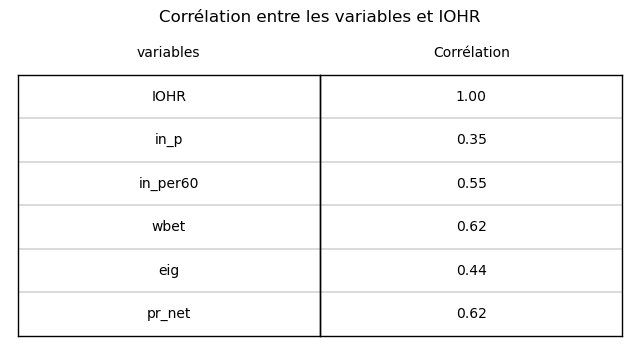

In [39]:
# garder seulemnt les colonnes numériques pour la corrélation
num_df = player_impact_df[["IOHR", "in_p", "in_per60", "wbet", "eig", "pr_net"]]

# calculer la corrélation de chaque variable avec le IOHR
corr_series = num_df.corr()["IOHR"].rename("IOHR_CORR")
corr_df = corr_series.reset_index()
corr_df.columns = ["Metric", "Correlation"]
corr_df = corr_df.set_index("Metric")

# illustrer la table de corrélation
fig, ax = plt.subplots(figsize=(8, 4))
Table(
    corr_df,
    ax=ax,
    column_definitions=[
        ColDef(
            name="Metric", title="variables", border="both", textprops={"ha": "center"}
        ),
        ColDef(
            name="Correlation",
            title="Corrélation",
            border="both",
            formatter="{:^.2f}",
            textprops={"ha": "center"},
        ),
    ],
    footer_divider=True,
)
plt.title("Corrélation entre les variables et IOHR")
plt.show()

Questions posées : 

Comment réduire le nombre immense de données récupérées? : les joueurs doivent avoir plus de 100 minutes jouées et on se concentre sur les jeux en zone offensives 

Comment adapter une idée de modèle pour le soccer (qui ont les 11 mêmes joueurs sur le terrain en quasi-permanence) à un jeu aussi dynamique que le hockey? = nous avons créer 2 types de pass networks. Le premier quantifie toute l’équipe. Le deuxième, des quintettes de joueurs. 

Comment déterminer la valeur d’une donnée, dans un contexte avec un océan aussi vaste? =nous avons filtré les données, puis les avons passé à travers plusieurs modèles. Nous avons aussi réduit ou augmenté le nombre de variables de différents modèles, les ajustant selon leur output. 

Apprentissages: 

Nous avons appris comment optimiser le runtime d’une cellule, notamment avec la librairie numpy. Au début, une de nos cellule prenait 1h. À la fin, elle en prenait 1 seconde.  

Nous avons fait un grand nombre de réflexions sur les bonnes données à mettre dans notre modèle. Nous ne voulions pas compliquer notre modèle, mais nous voulions aussi avoir une vue englobante et précise de la performance d’un joueur, tout en prenant soin de bien évaluer l’impact hors-rondelle. Simplifié les feautures pour ne pas avoir de data leakage ou trop de bruits (12 features -> 6)